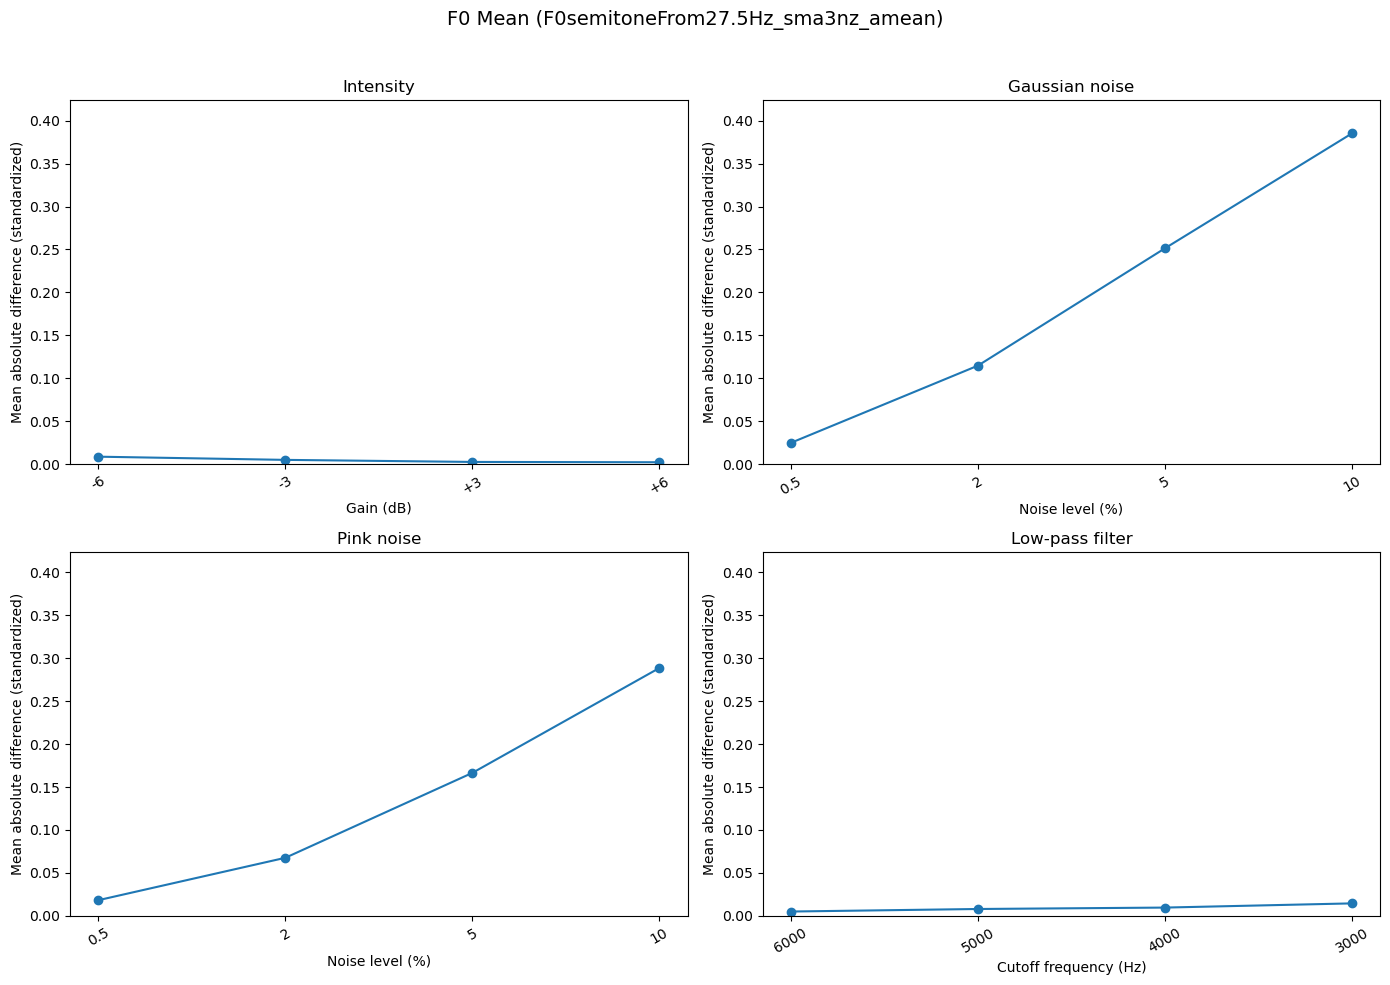

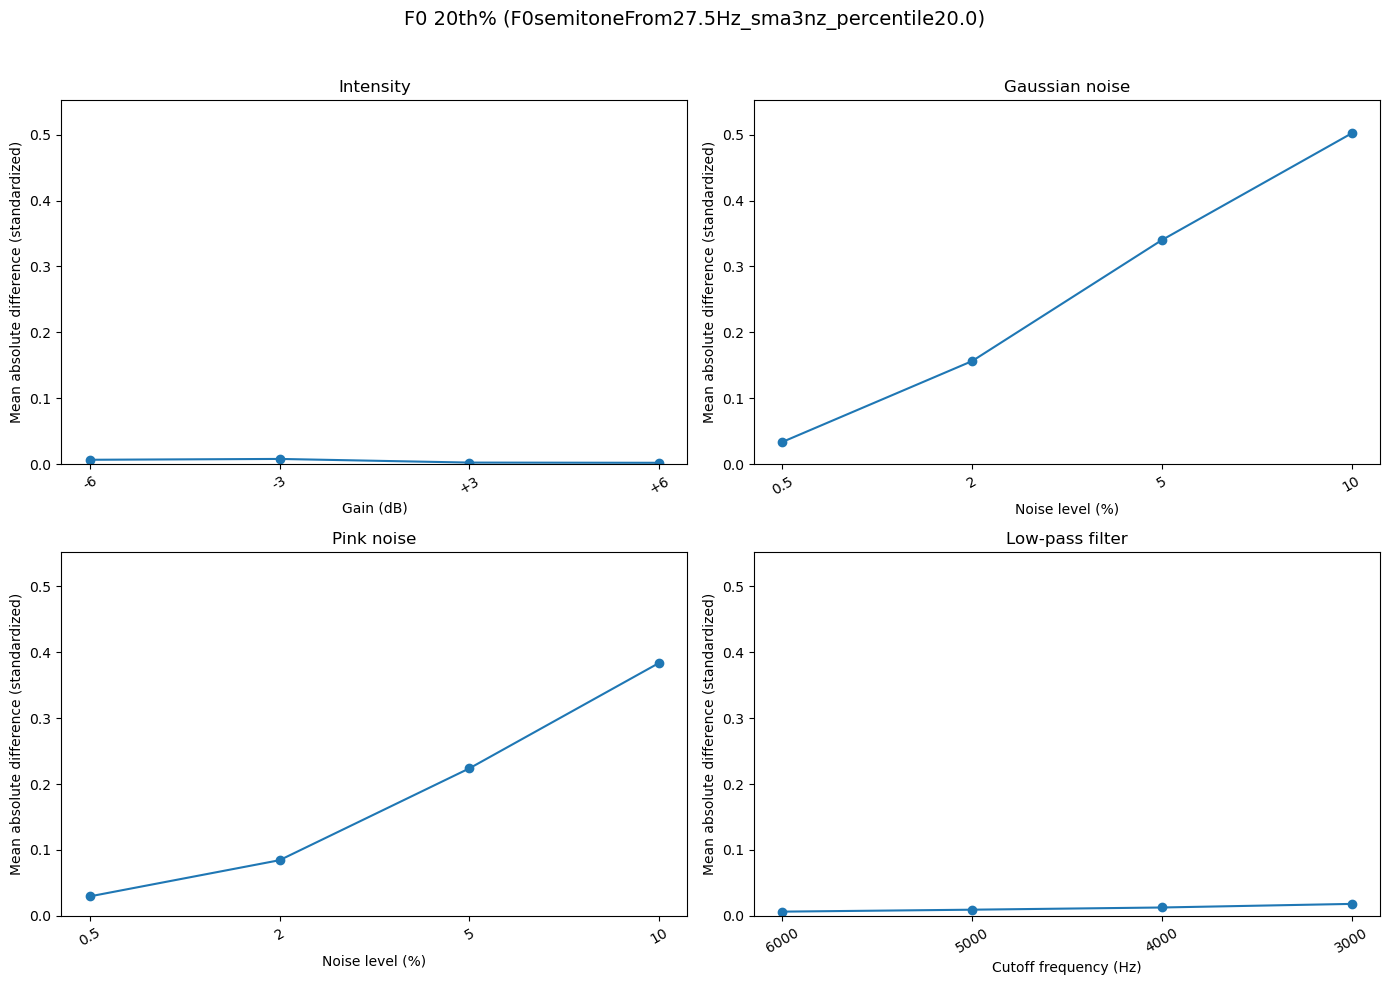

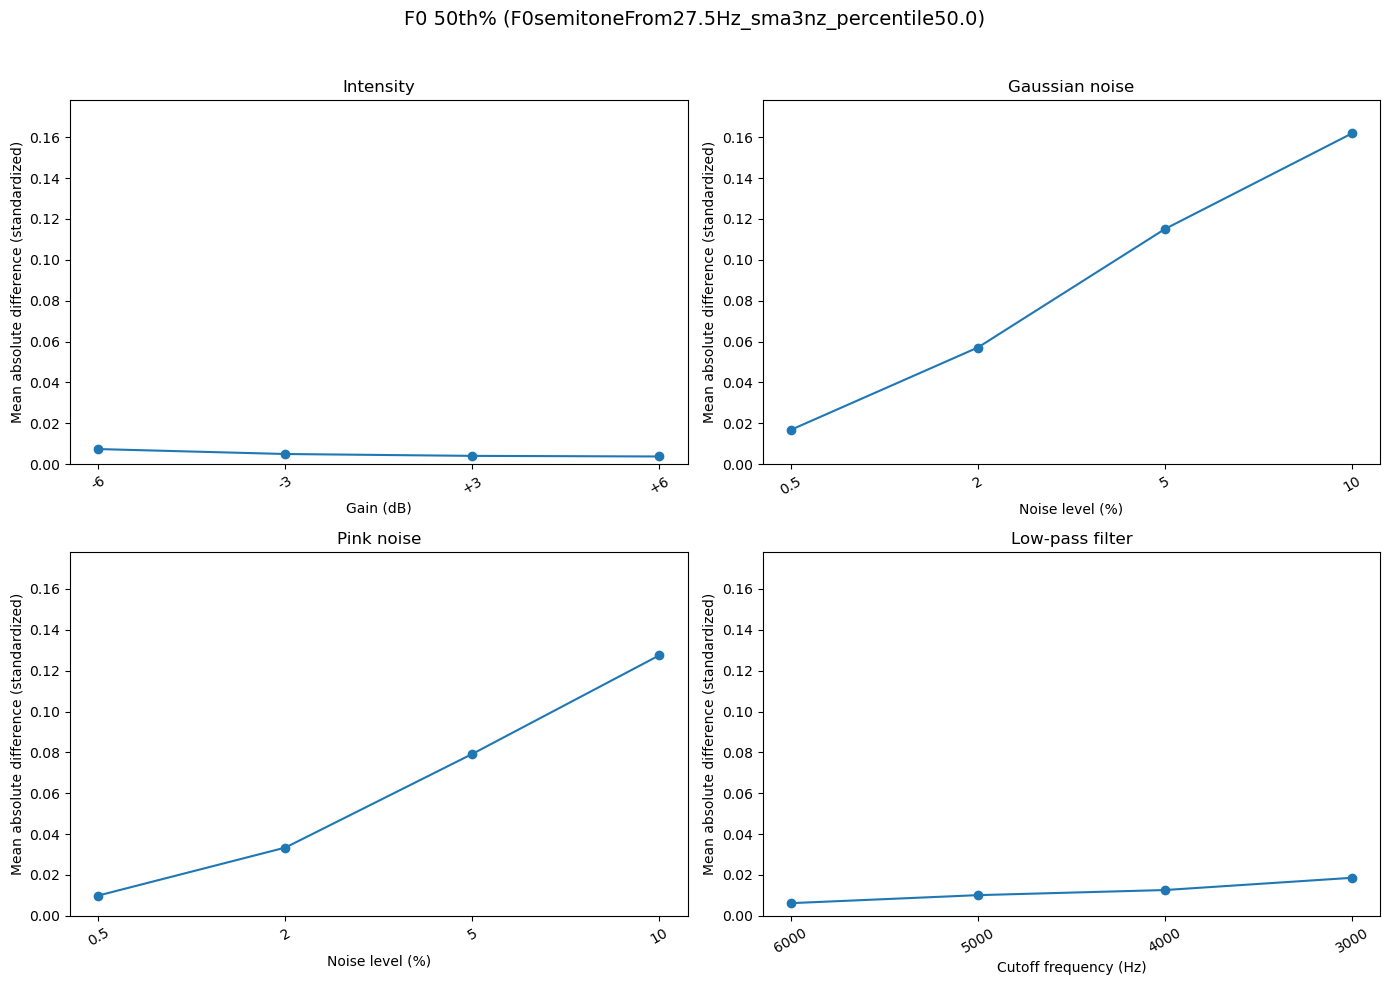

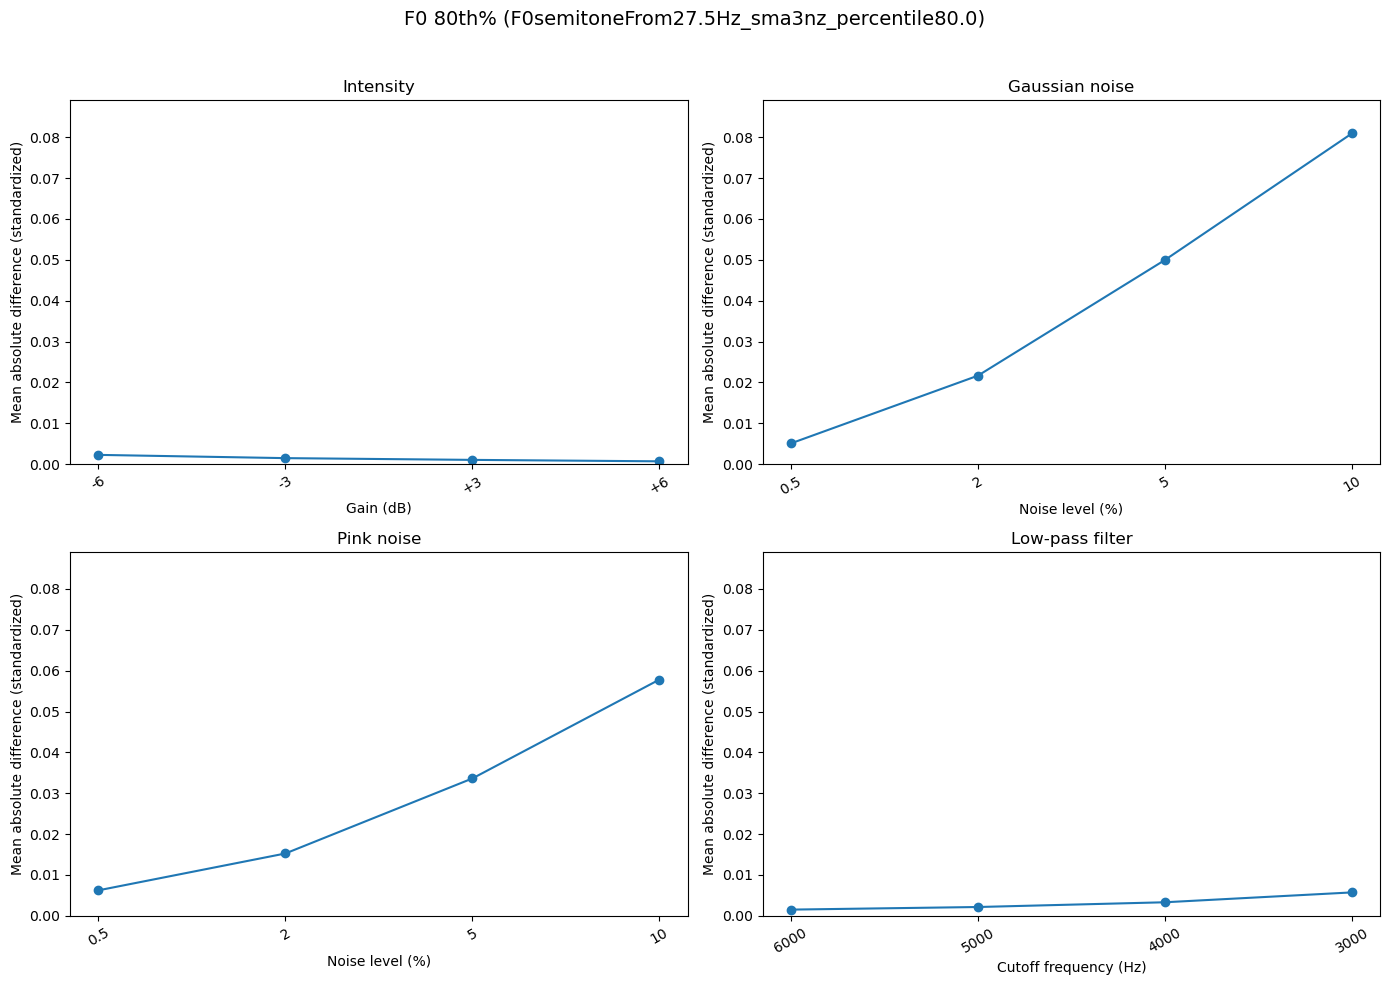

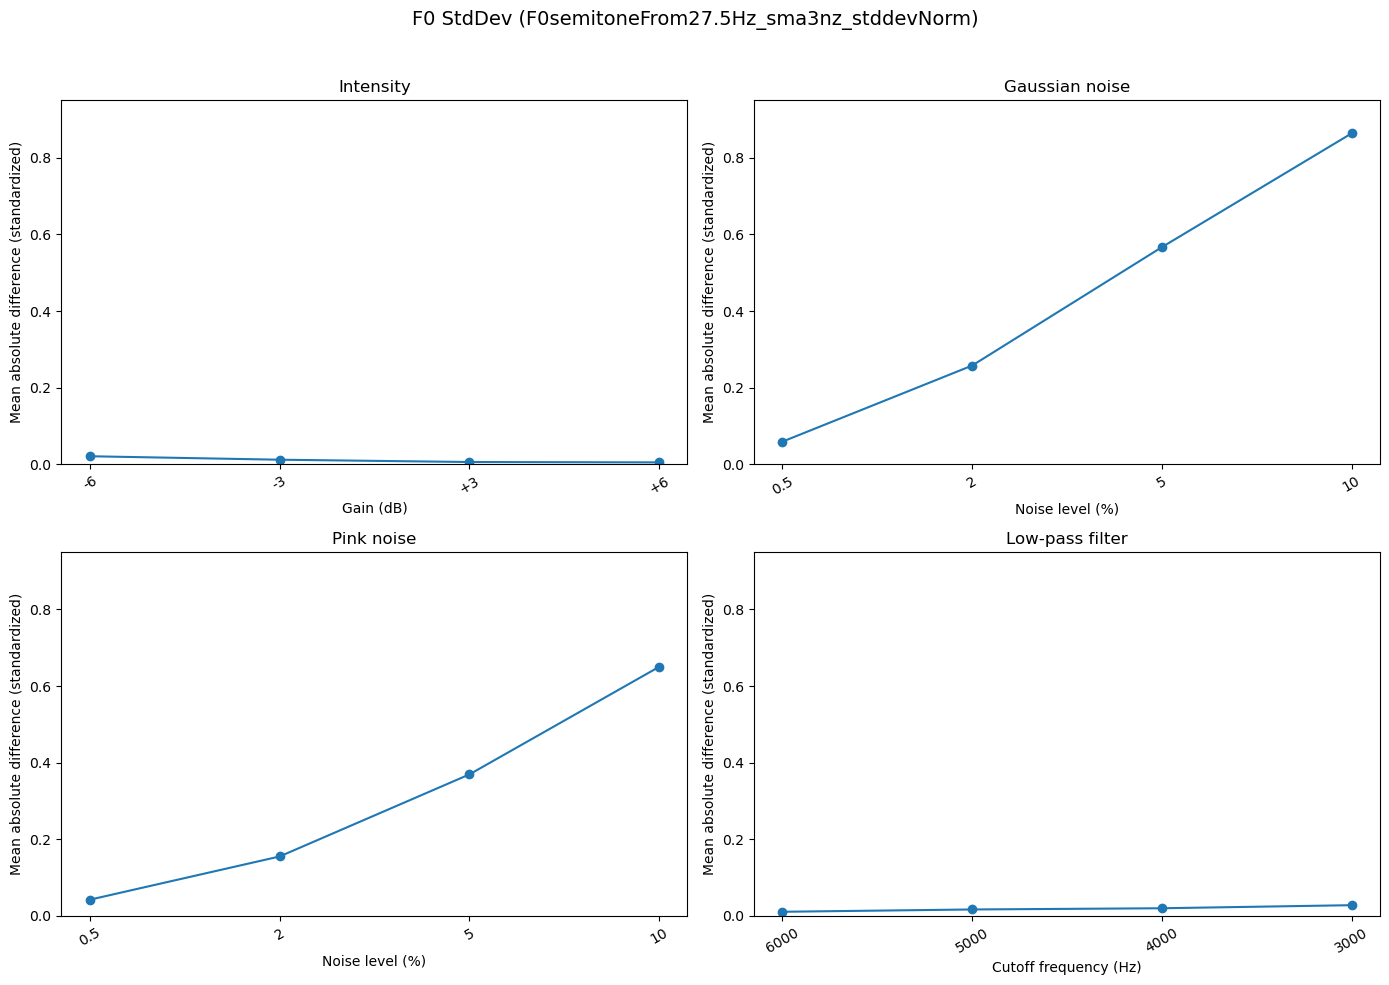

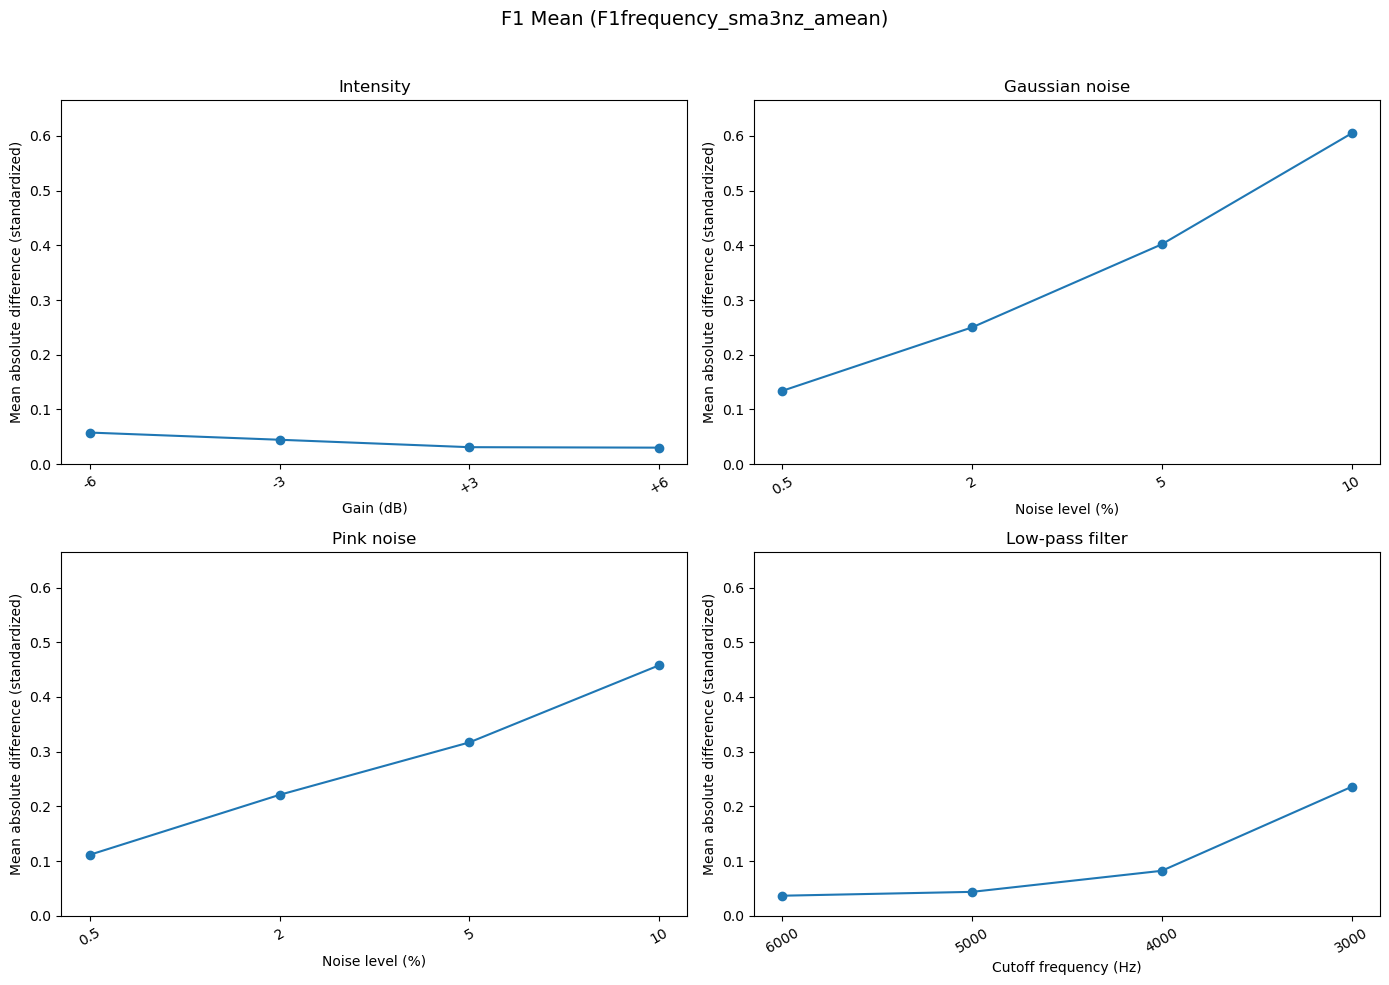

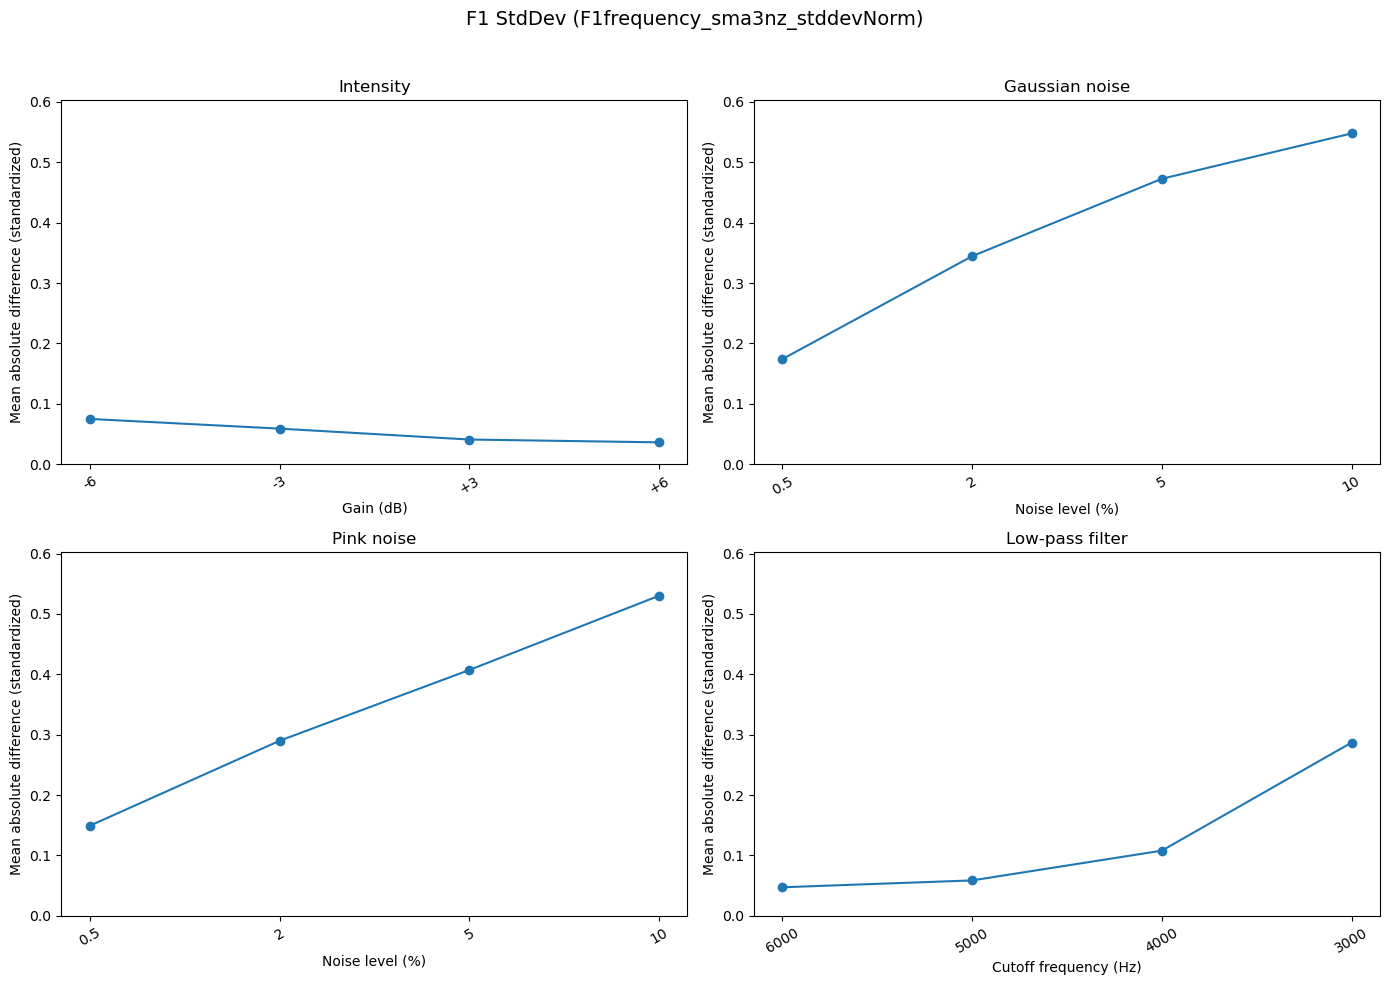

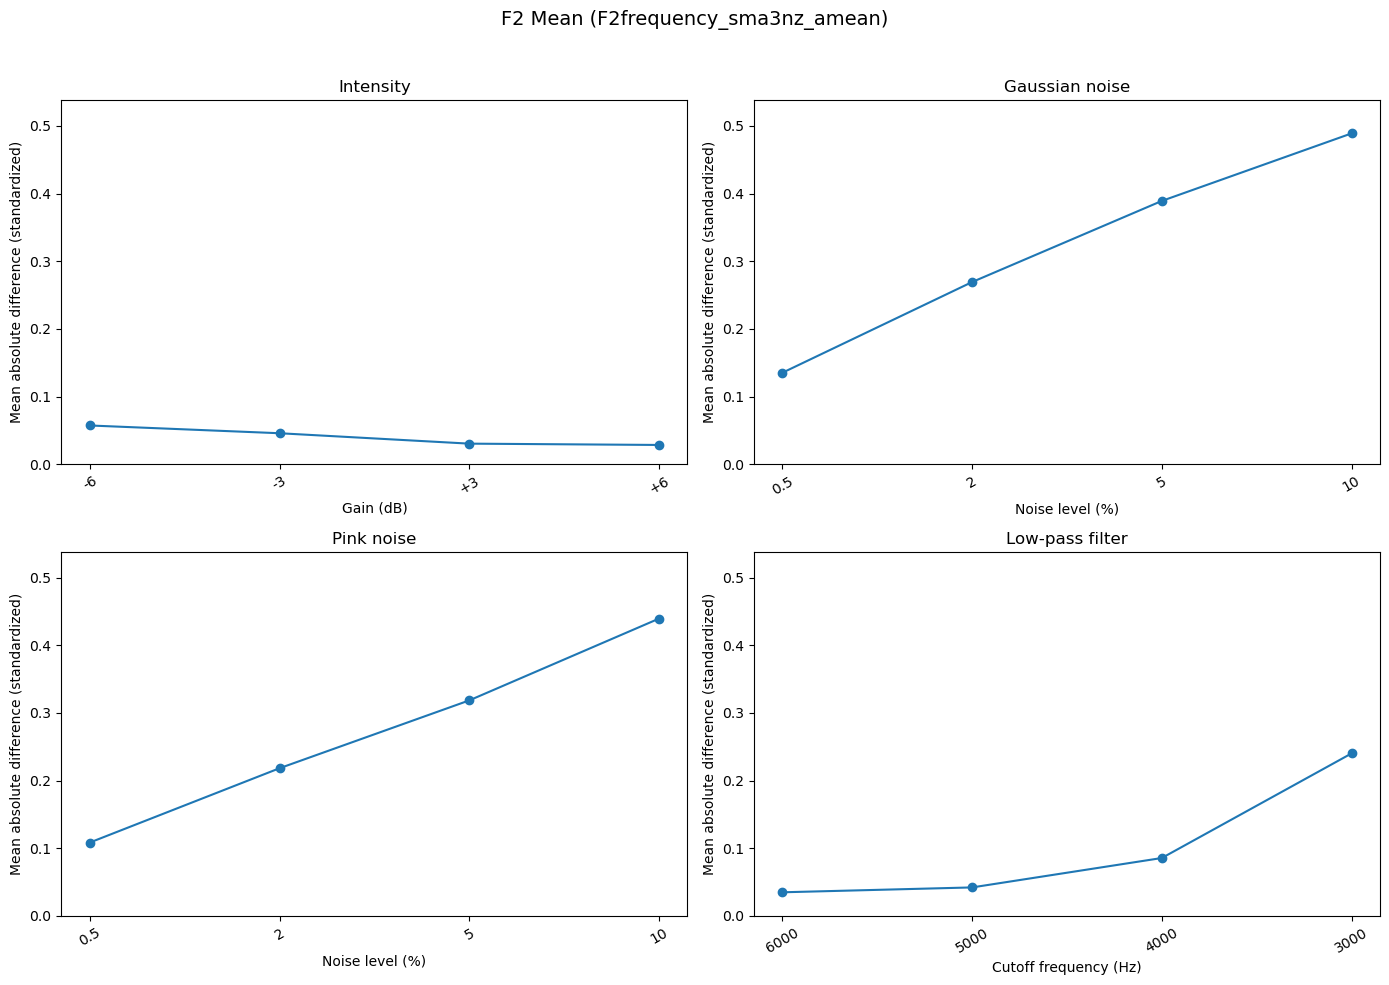

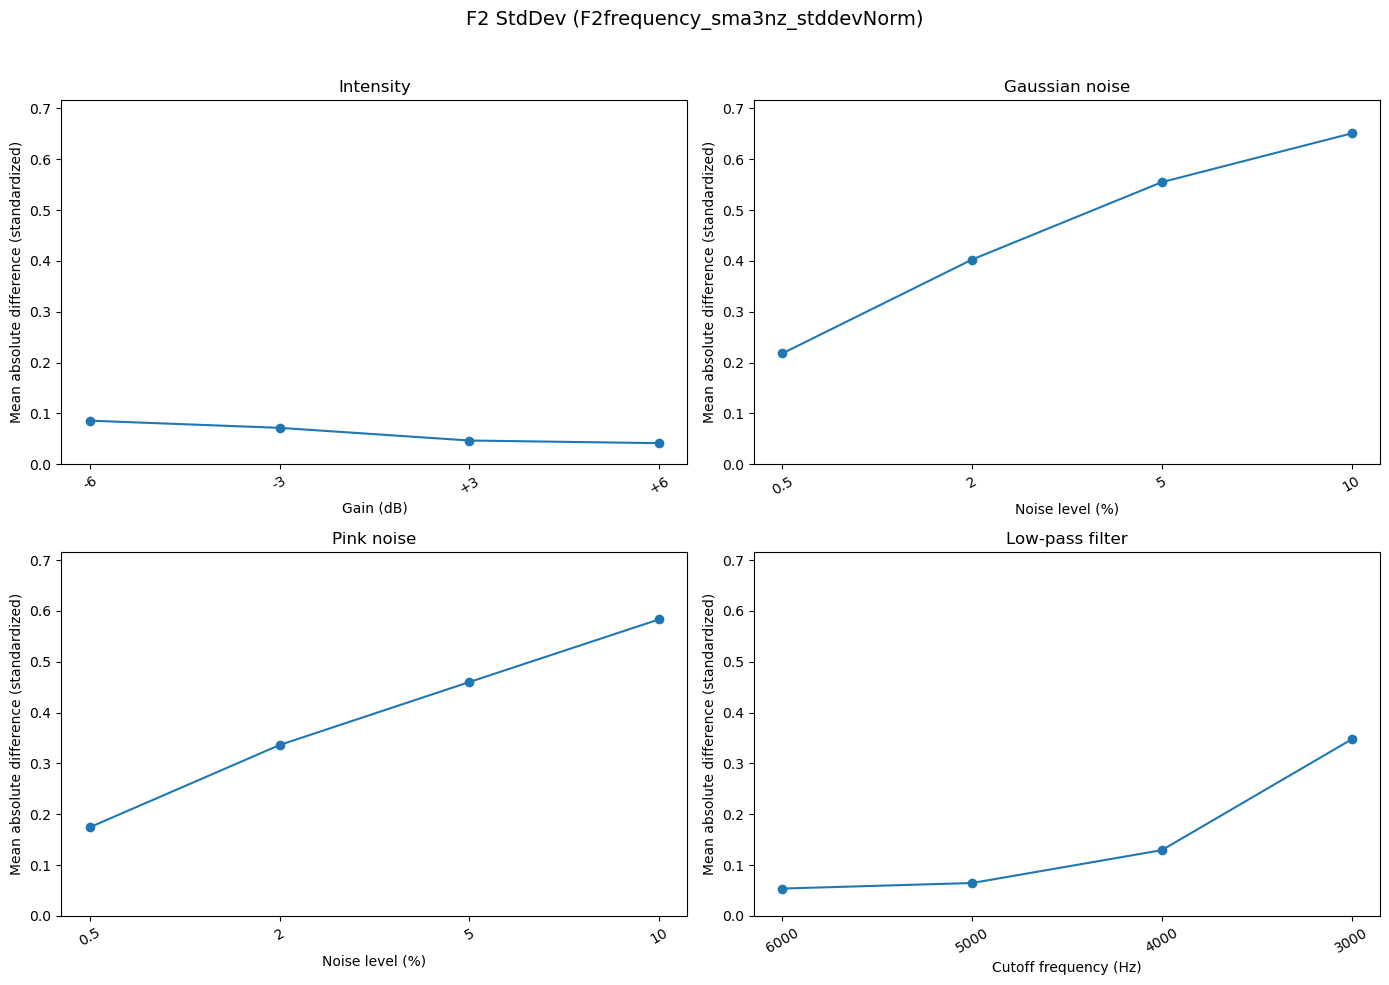

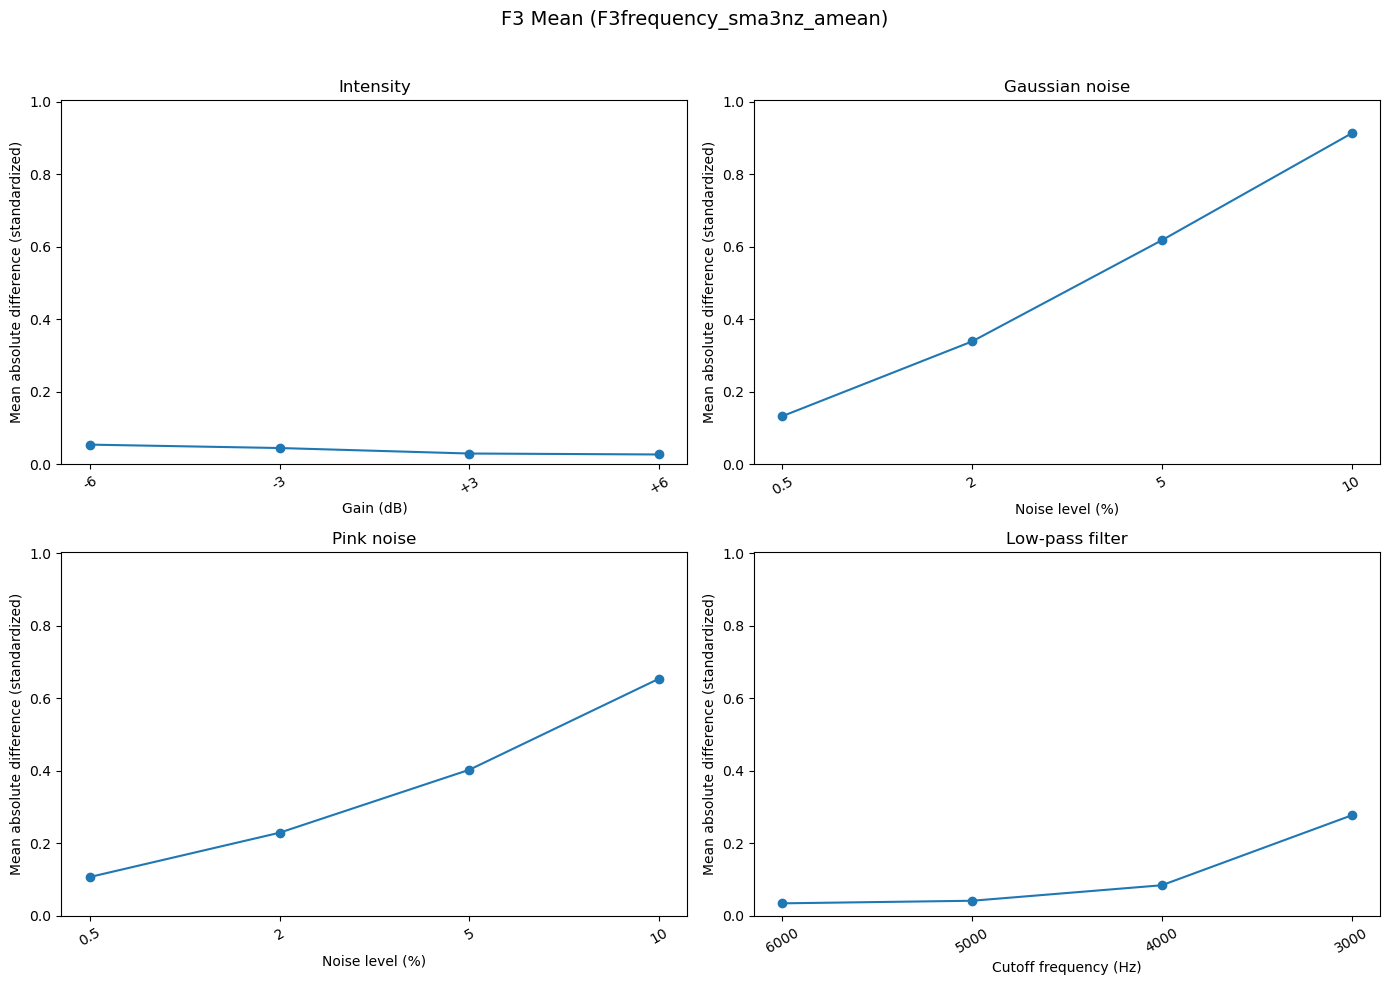

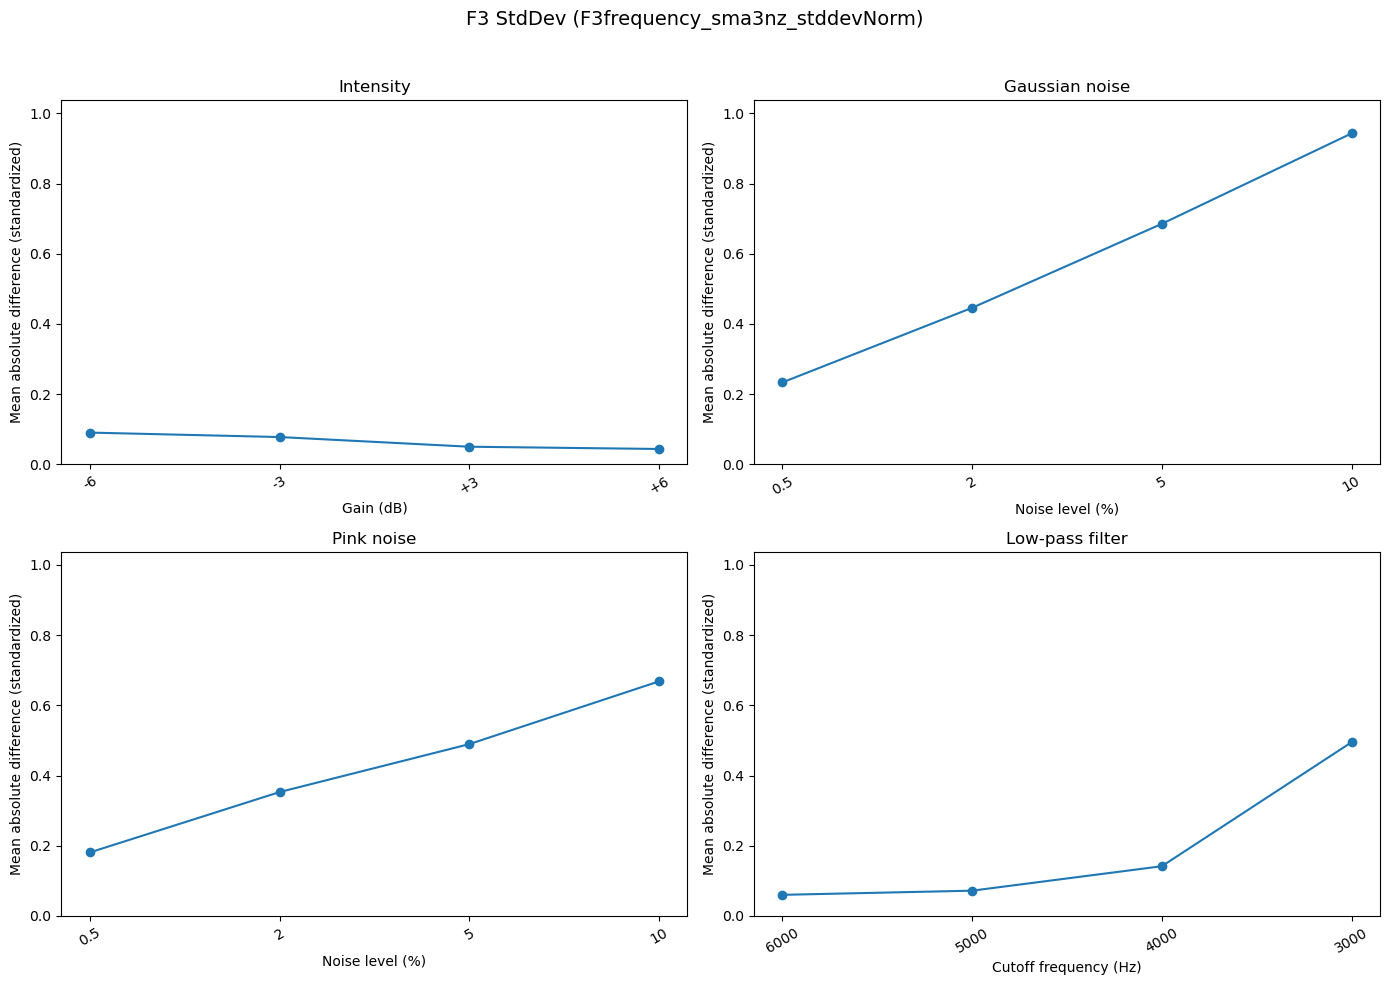

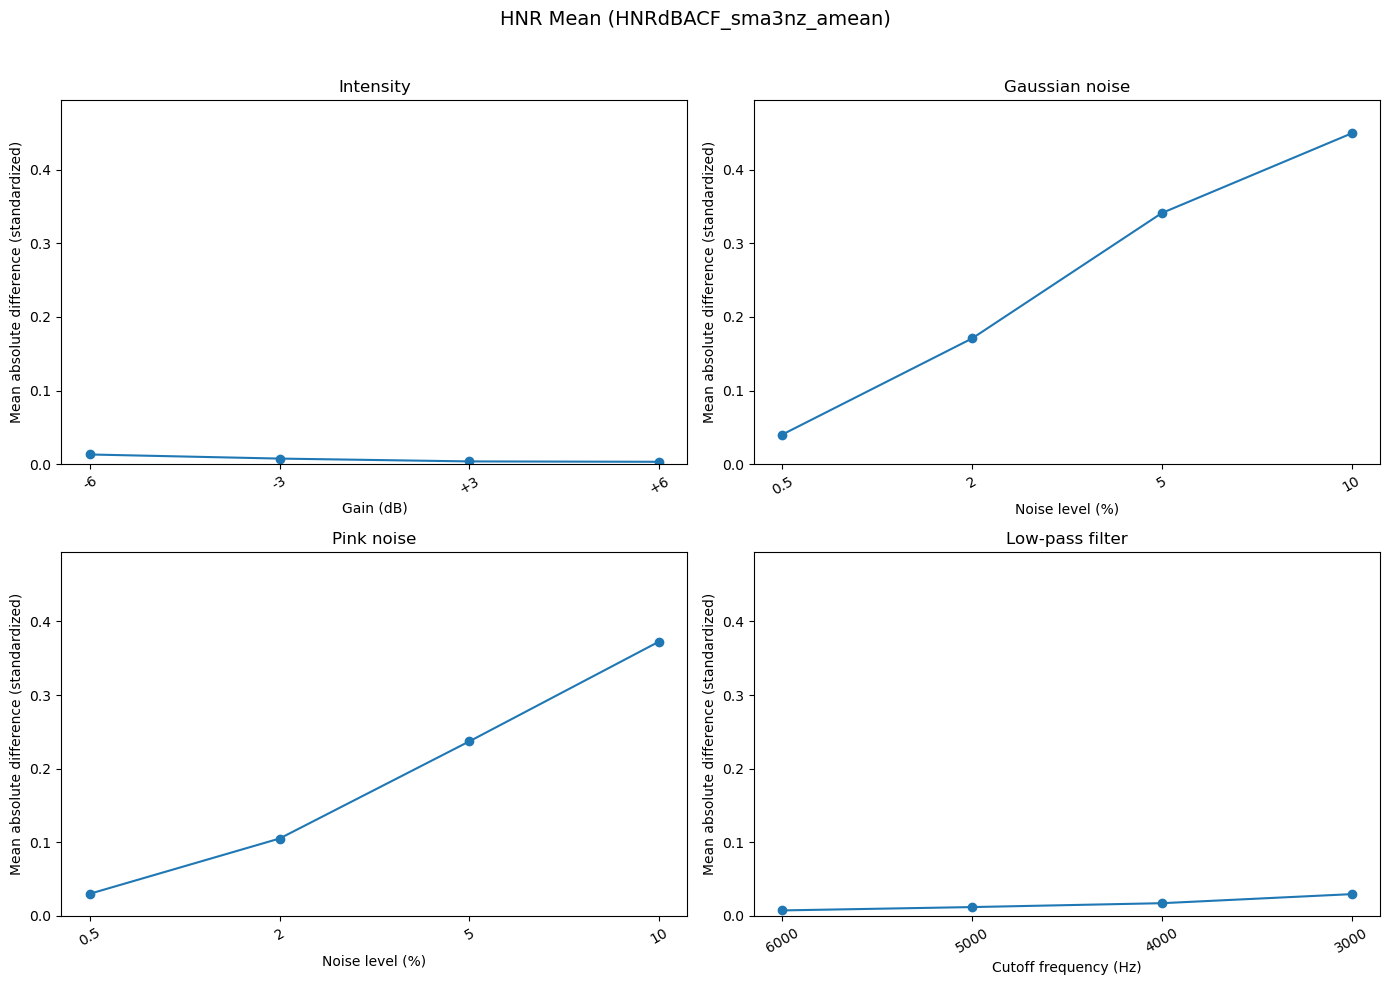

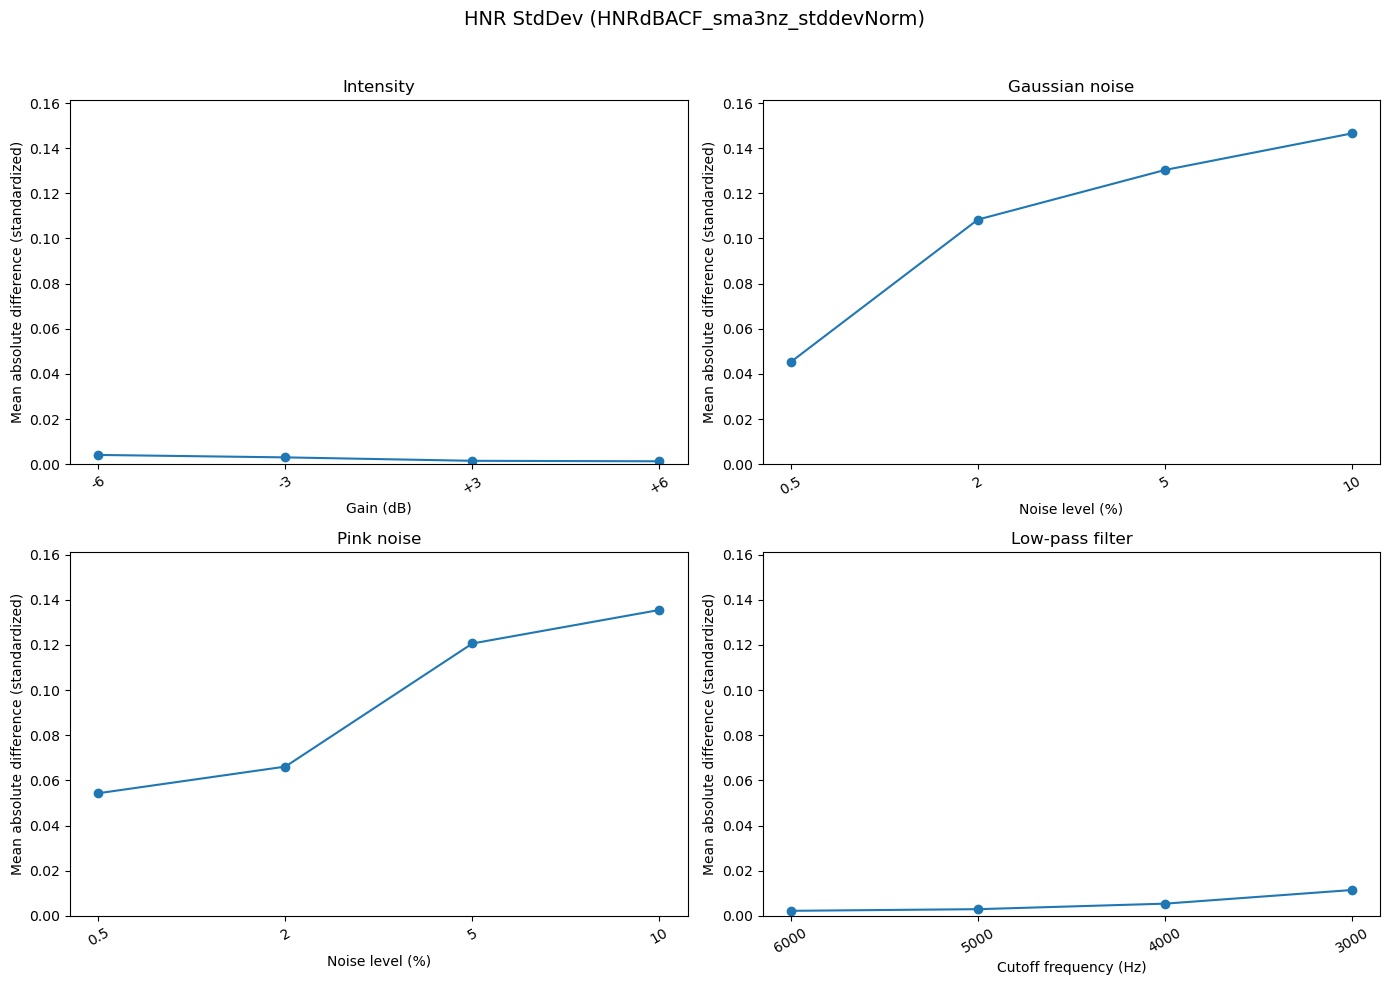

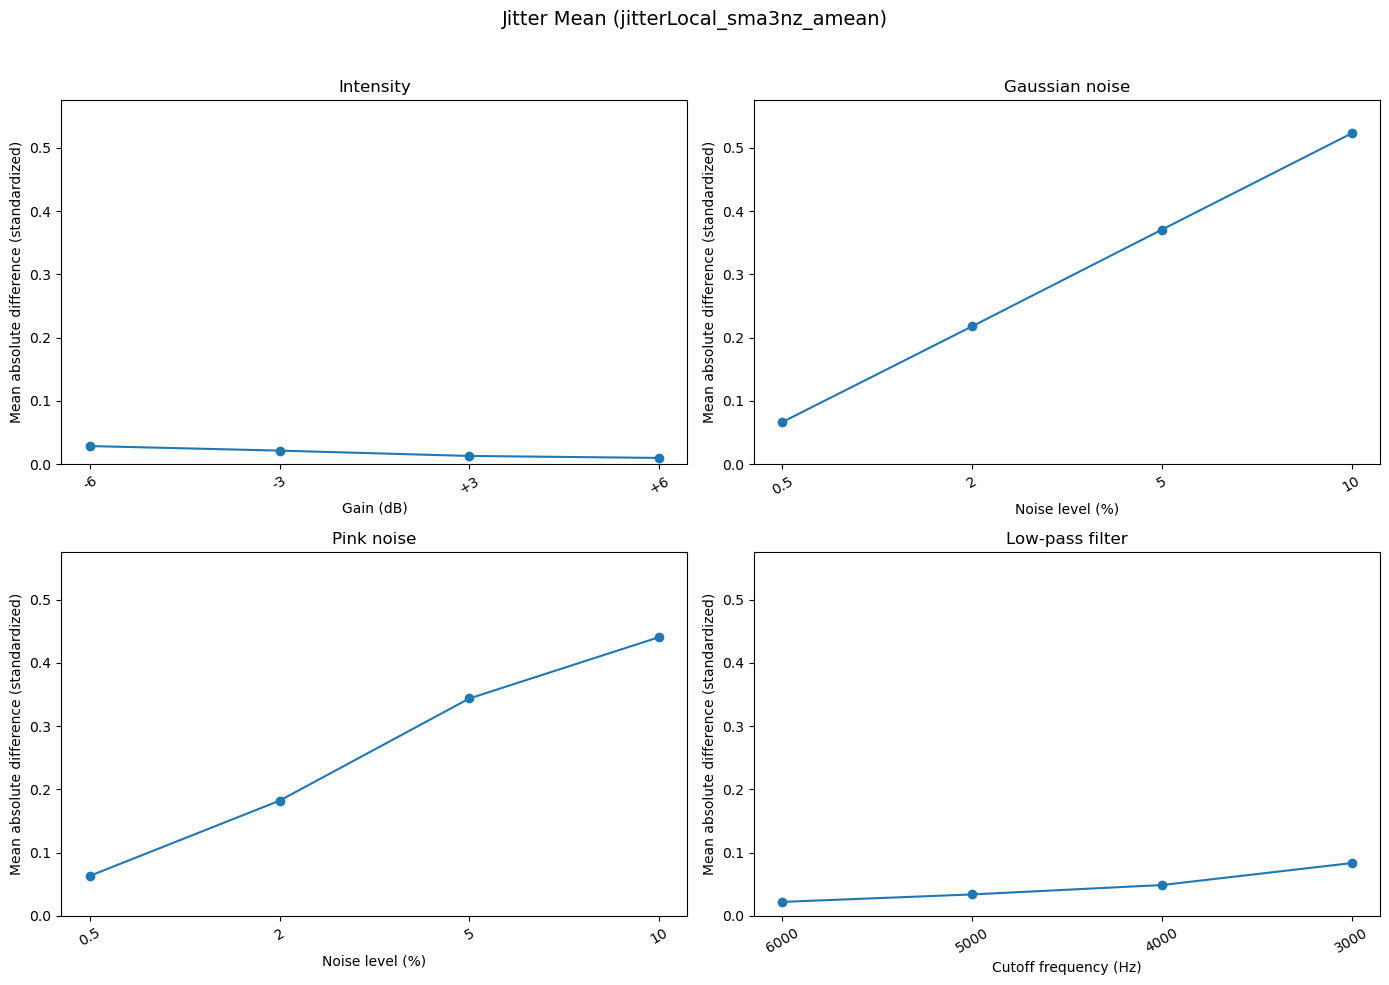

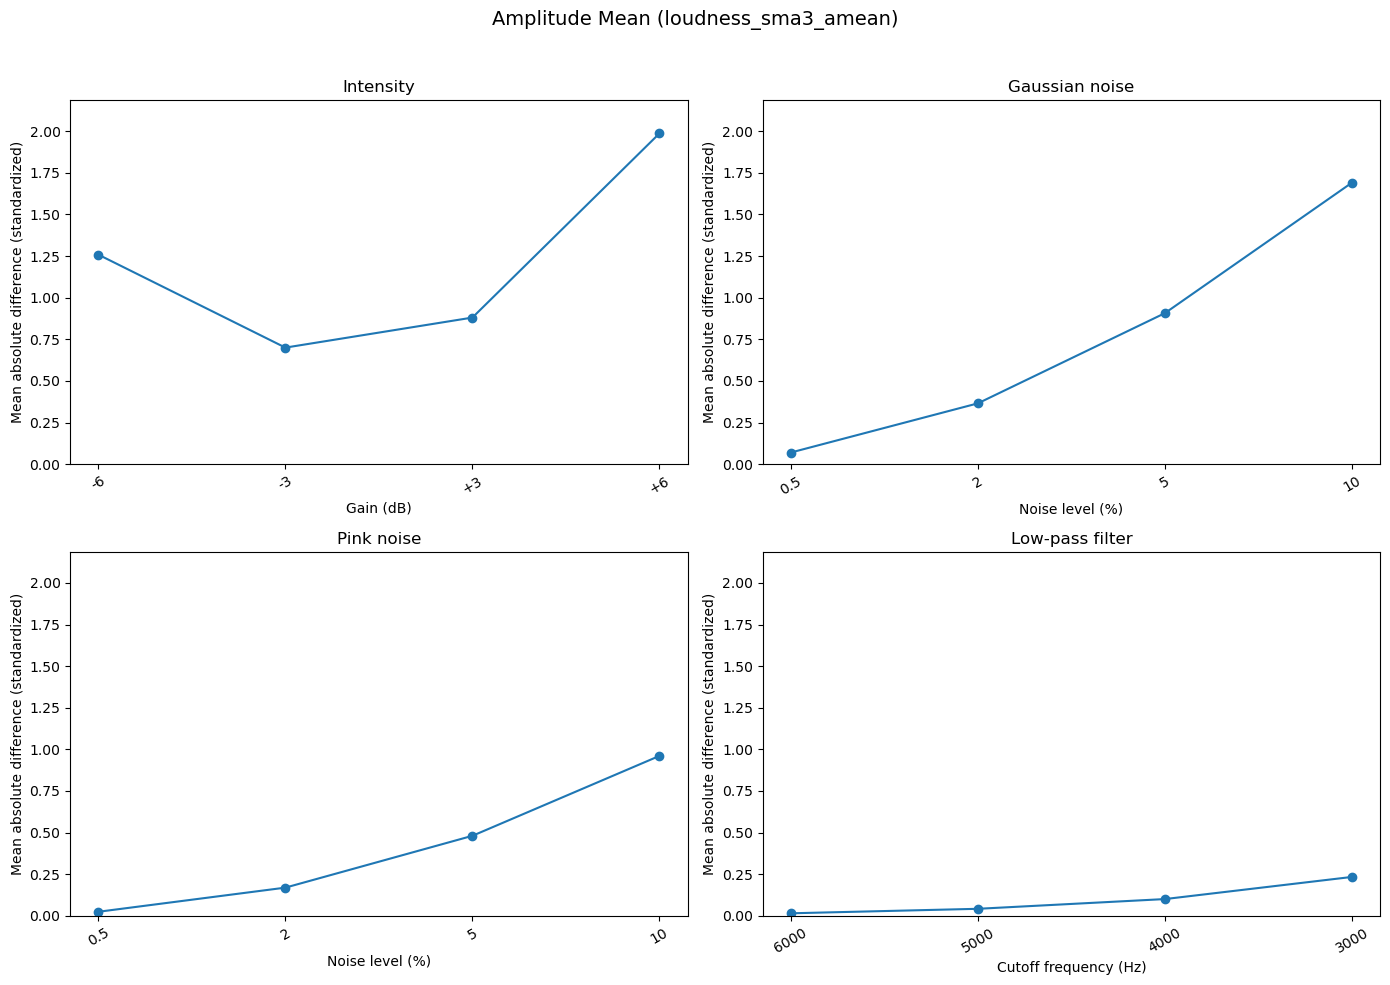

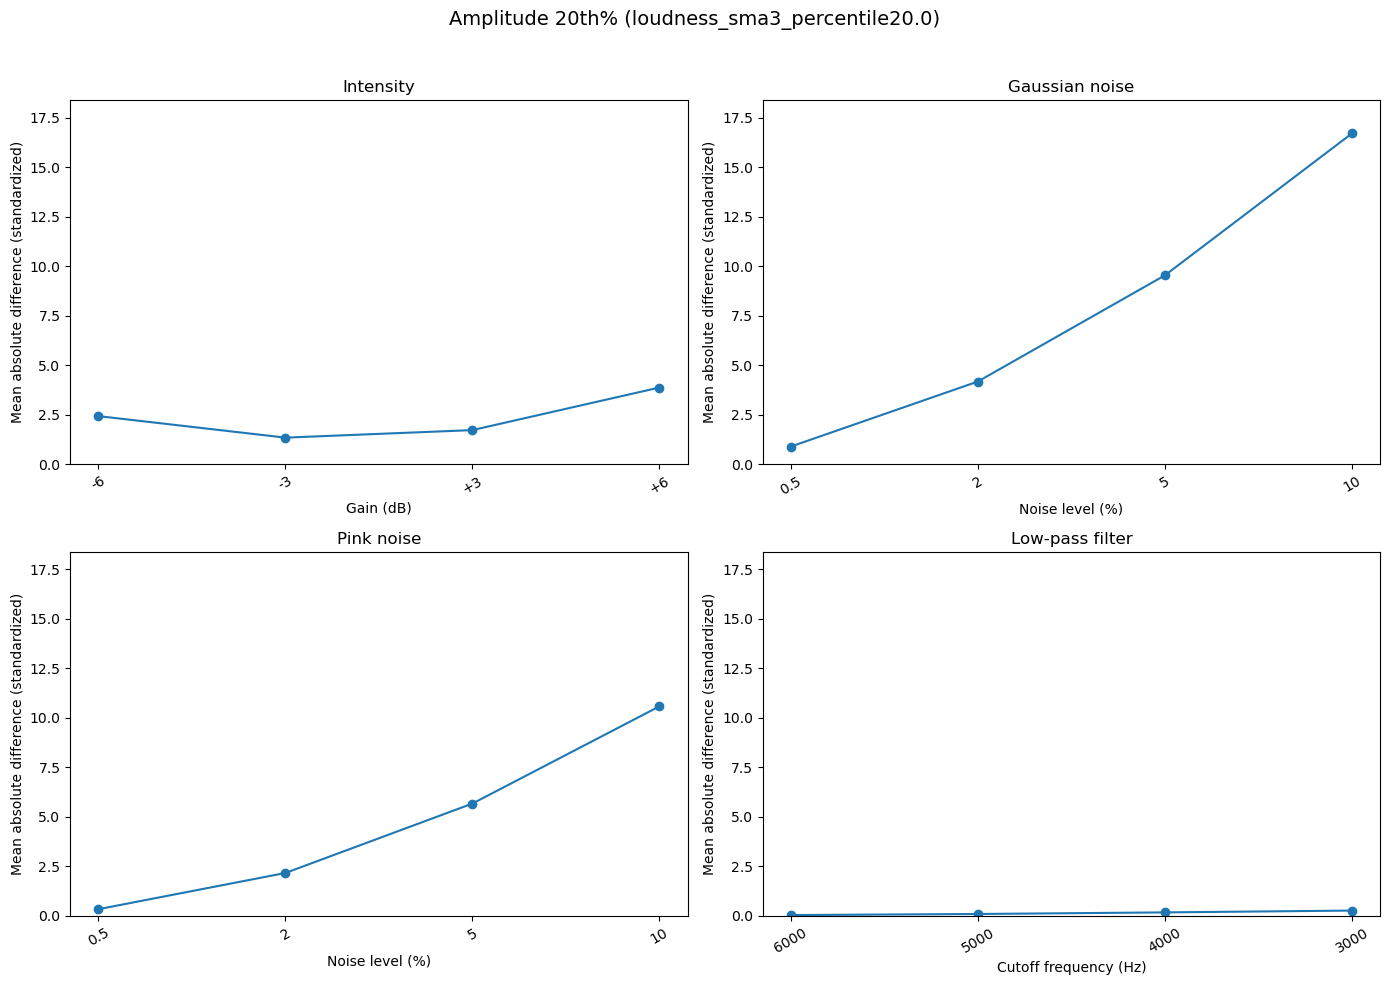

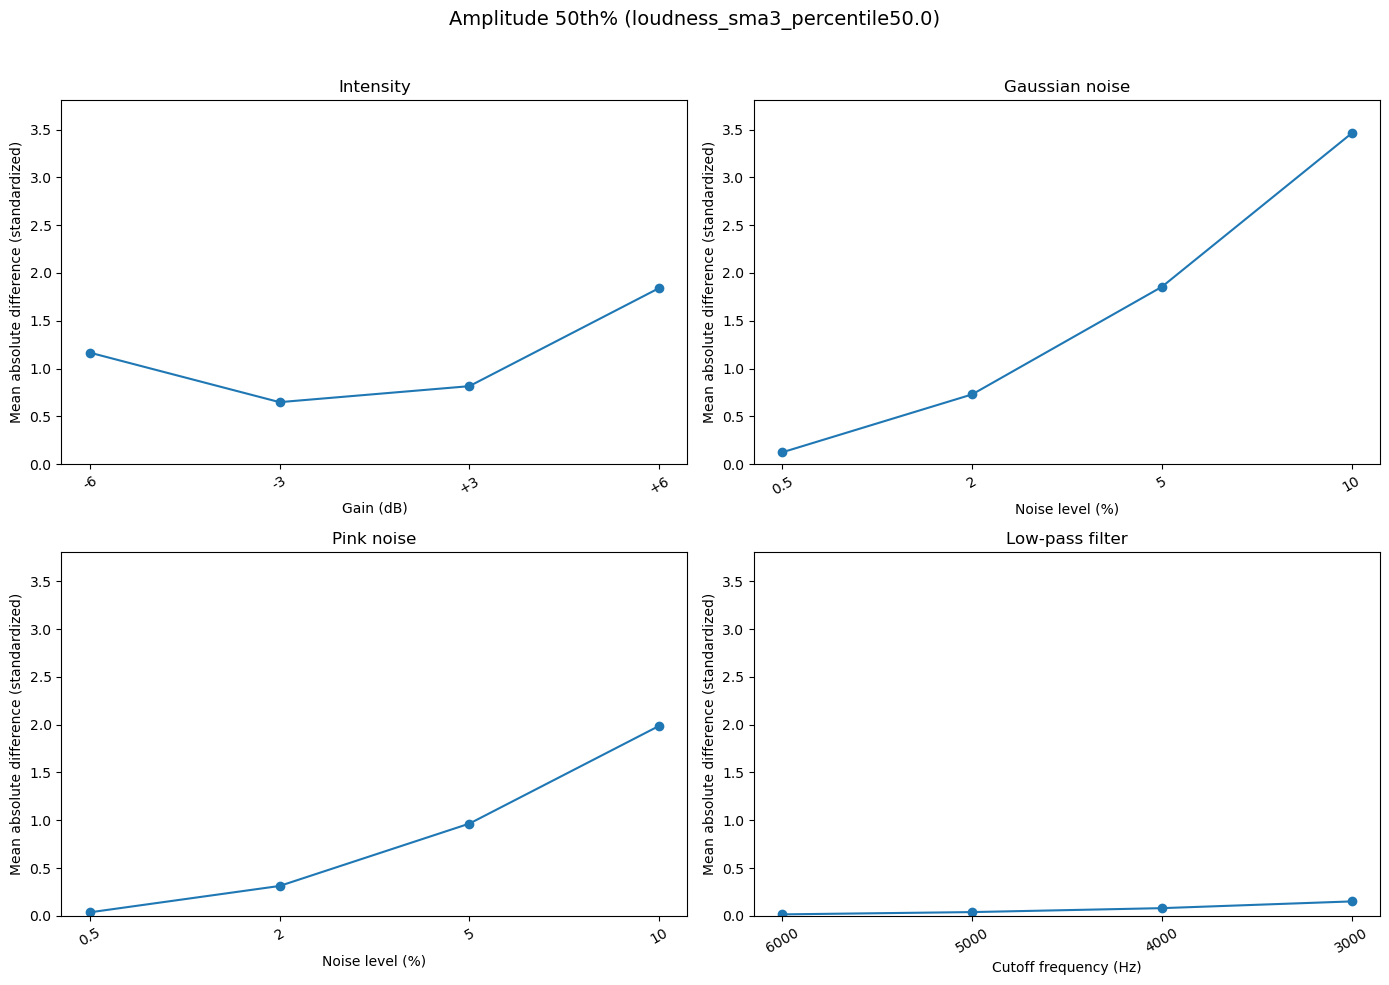

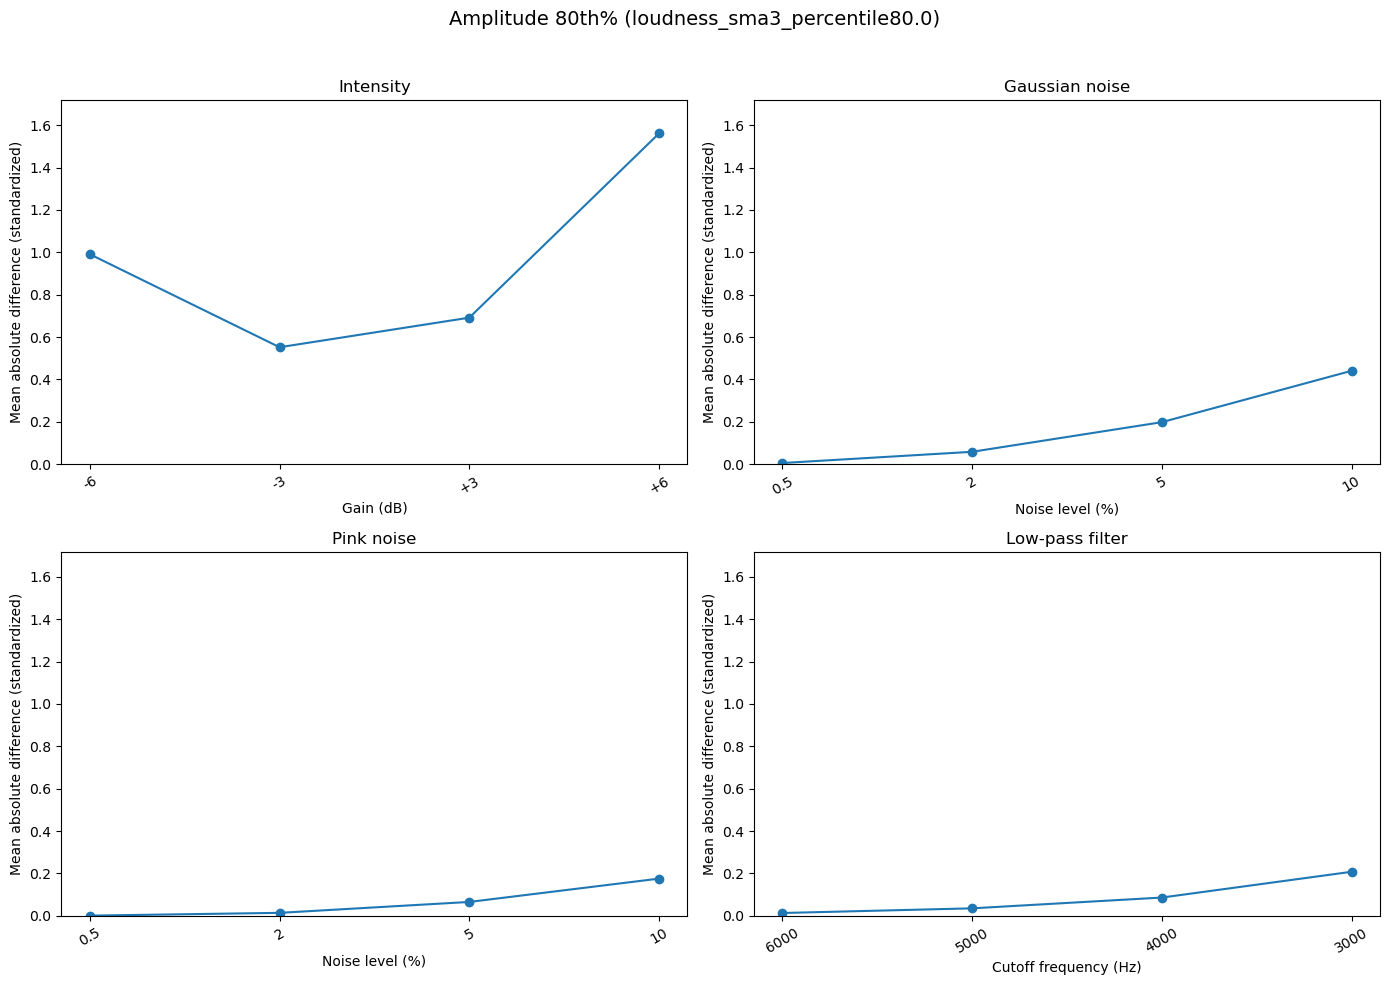

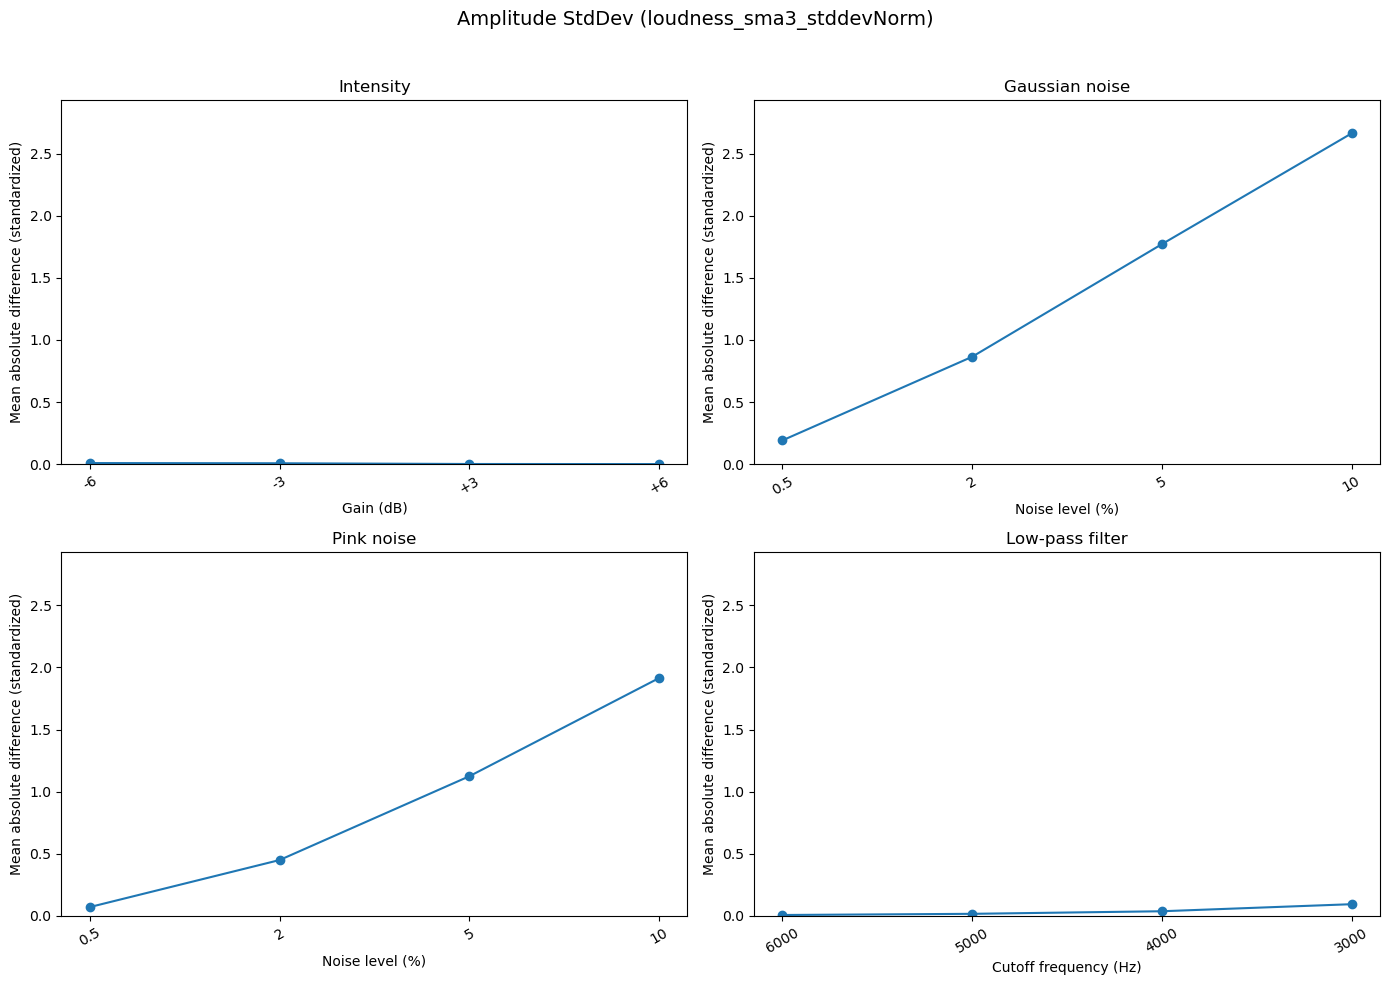

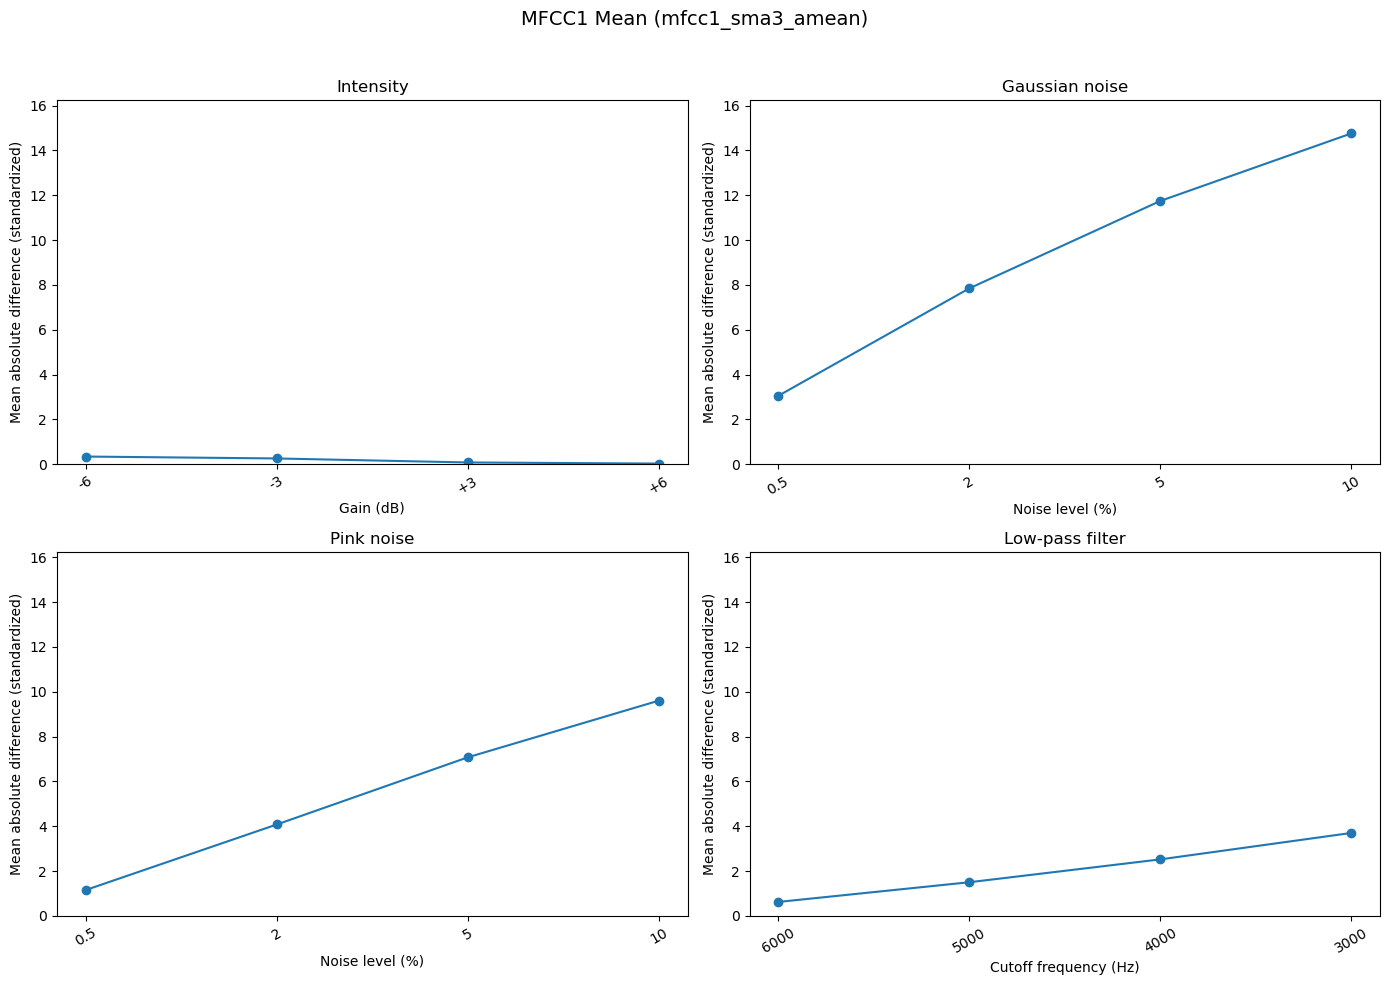

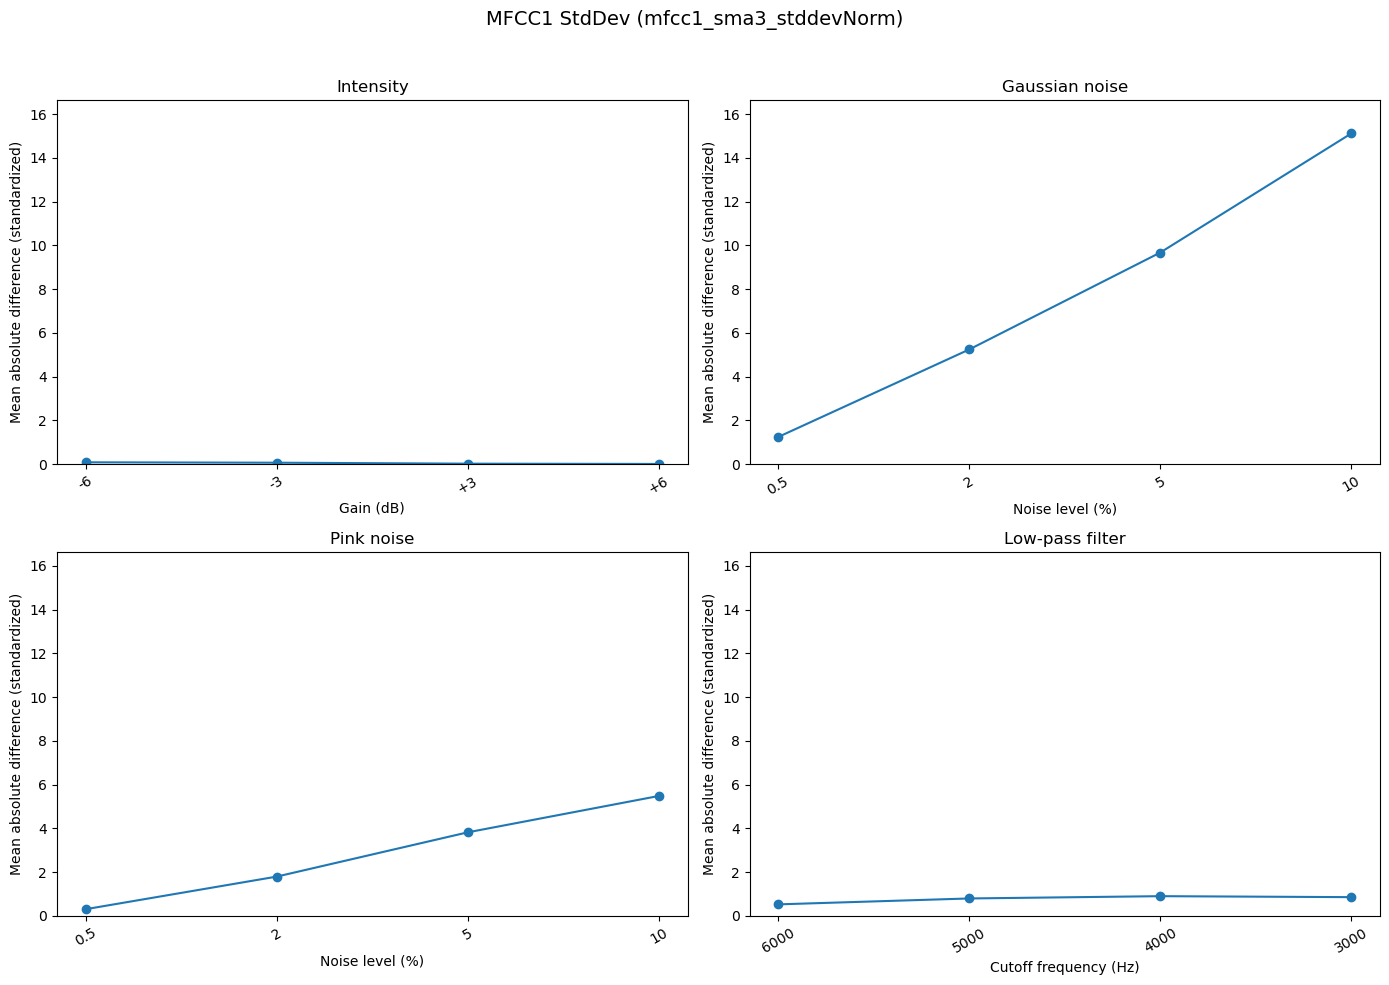

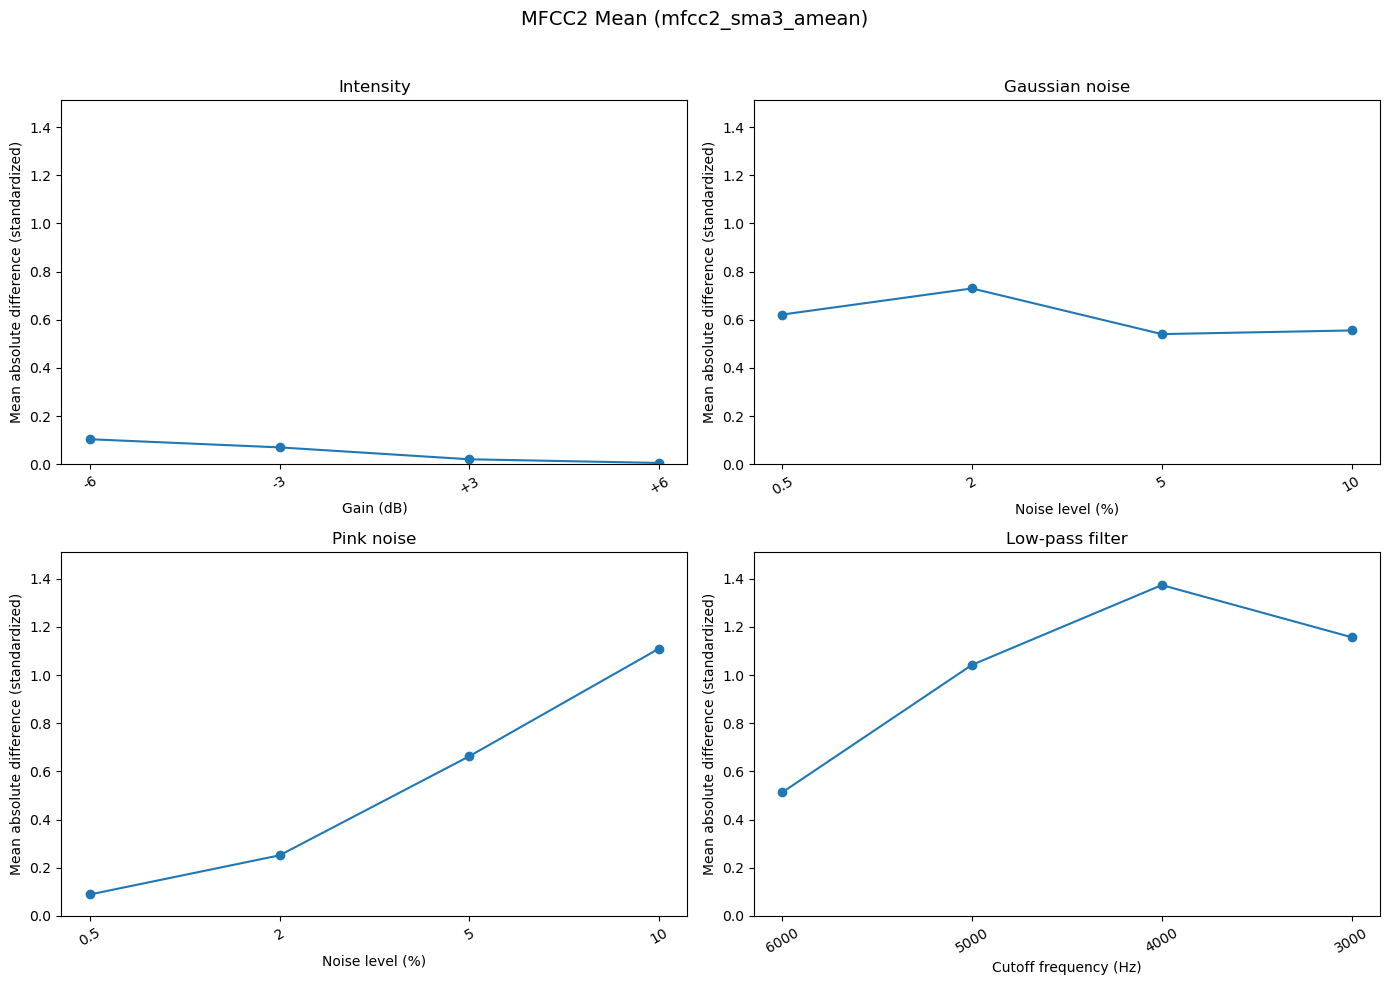

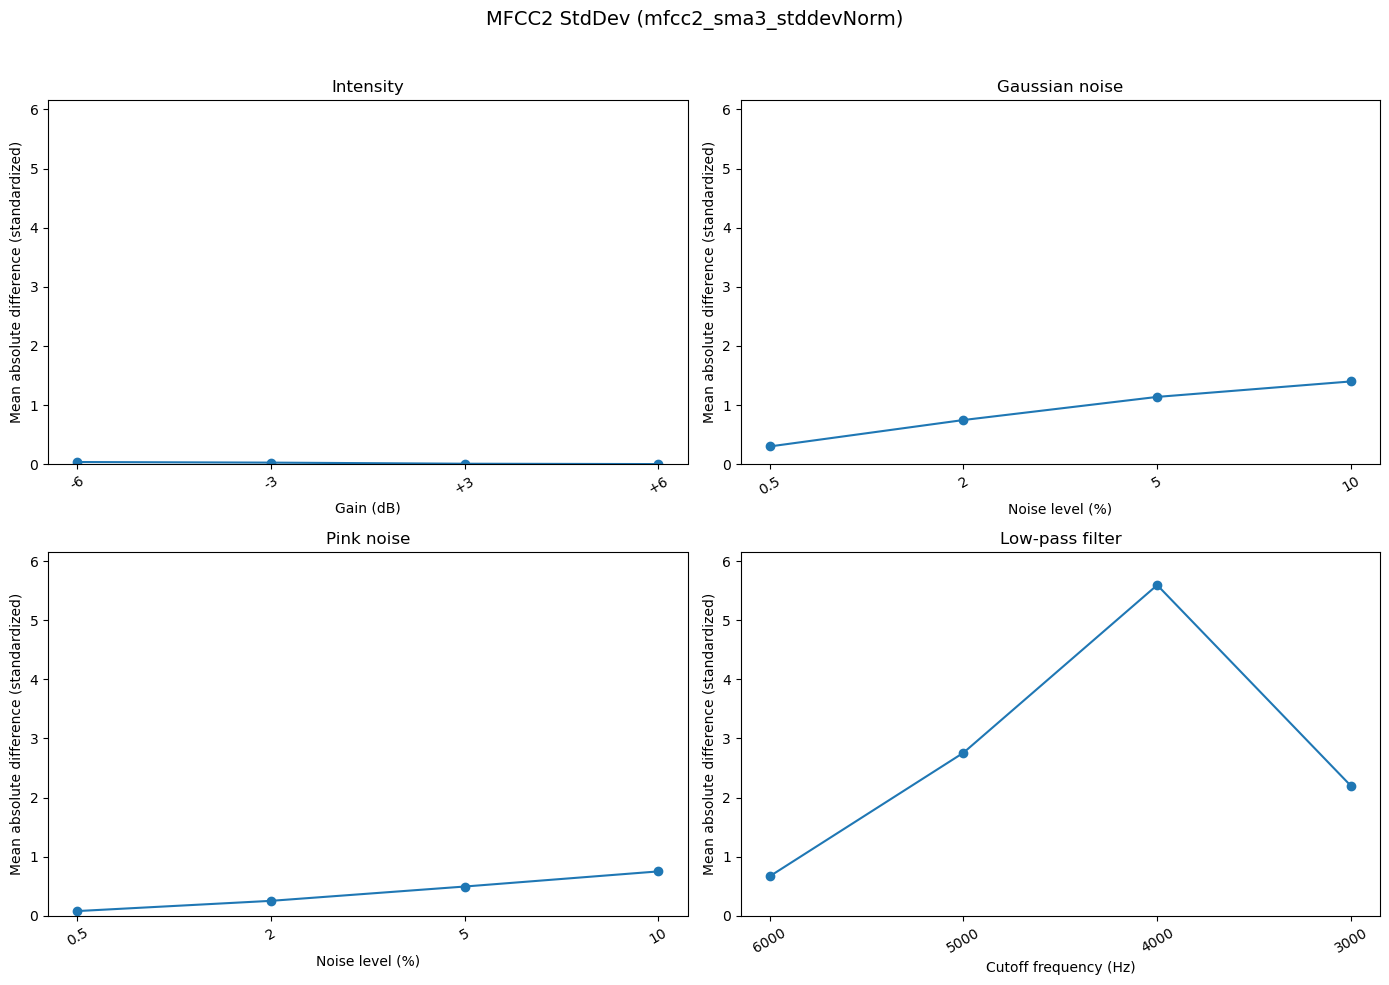

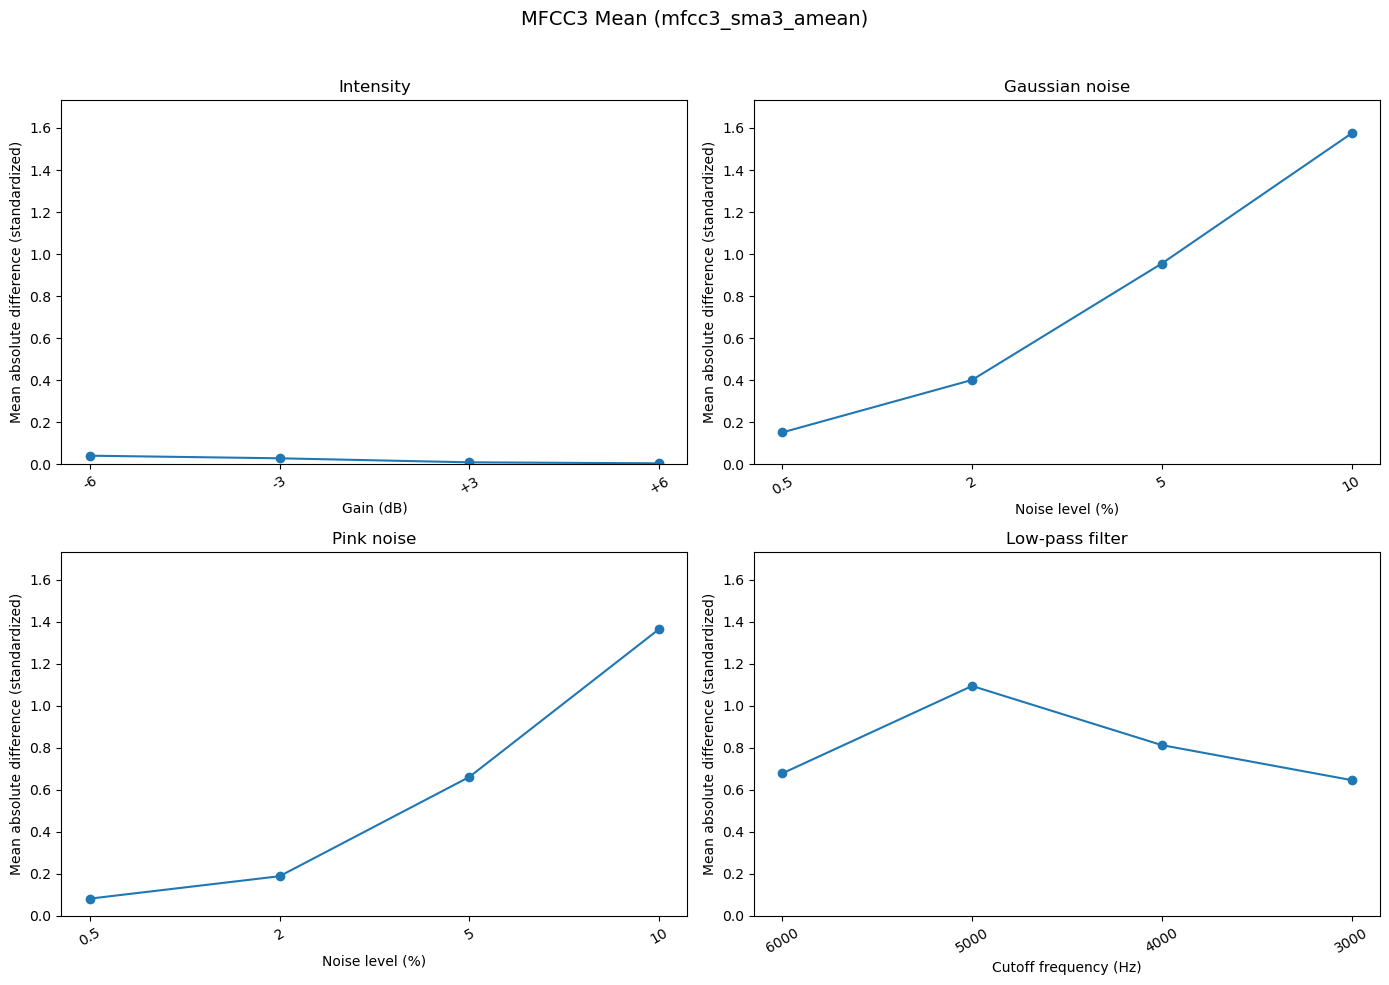

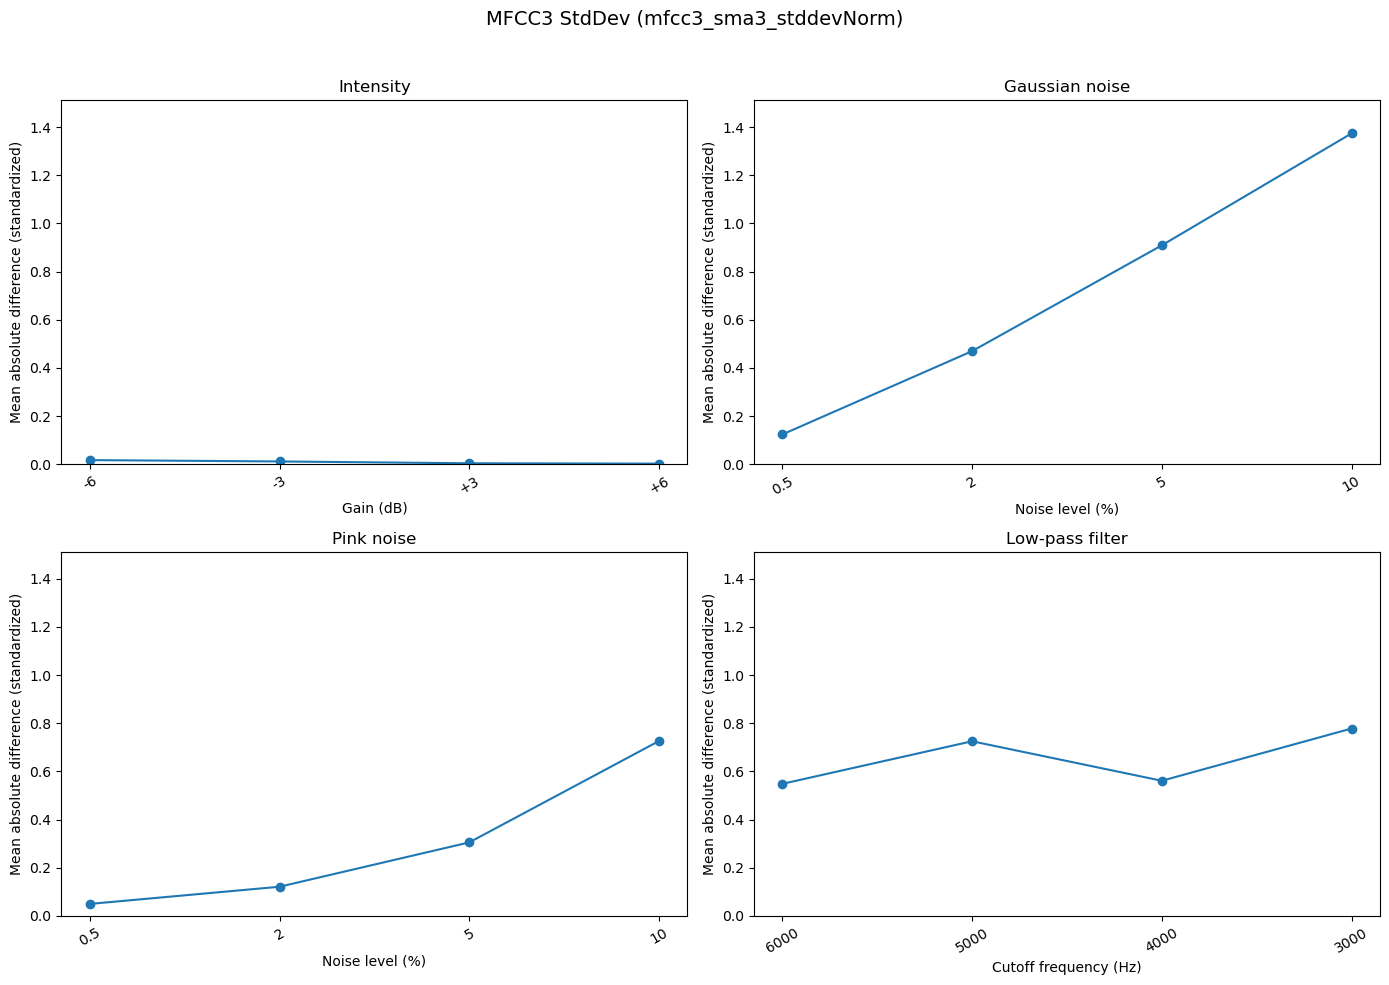

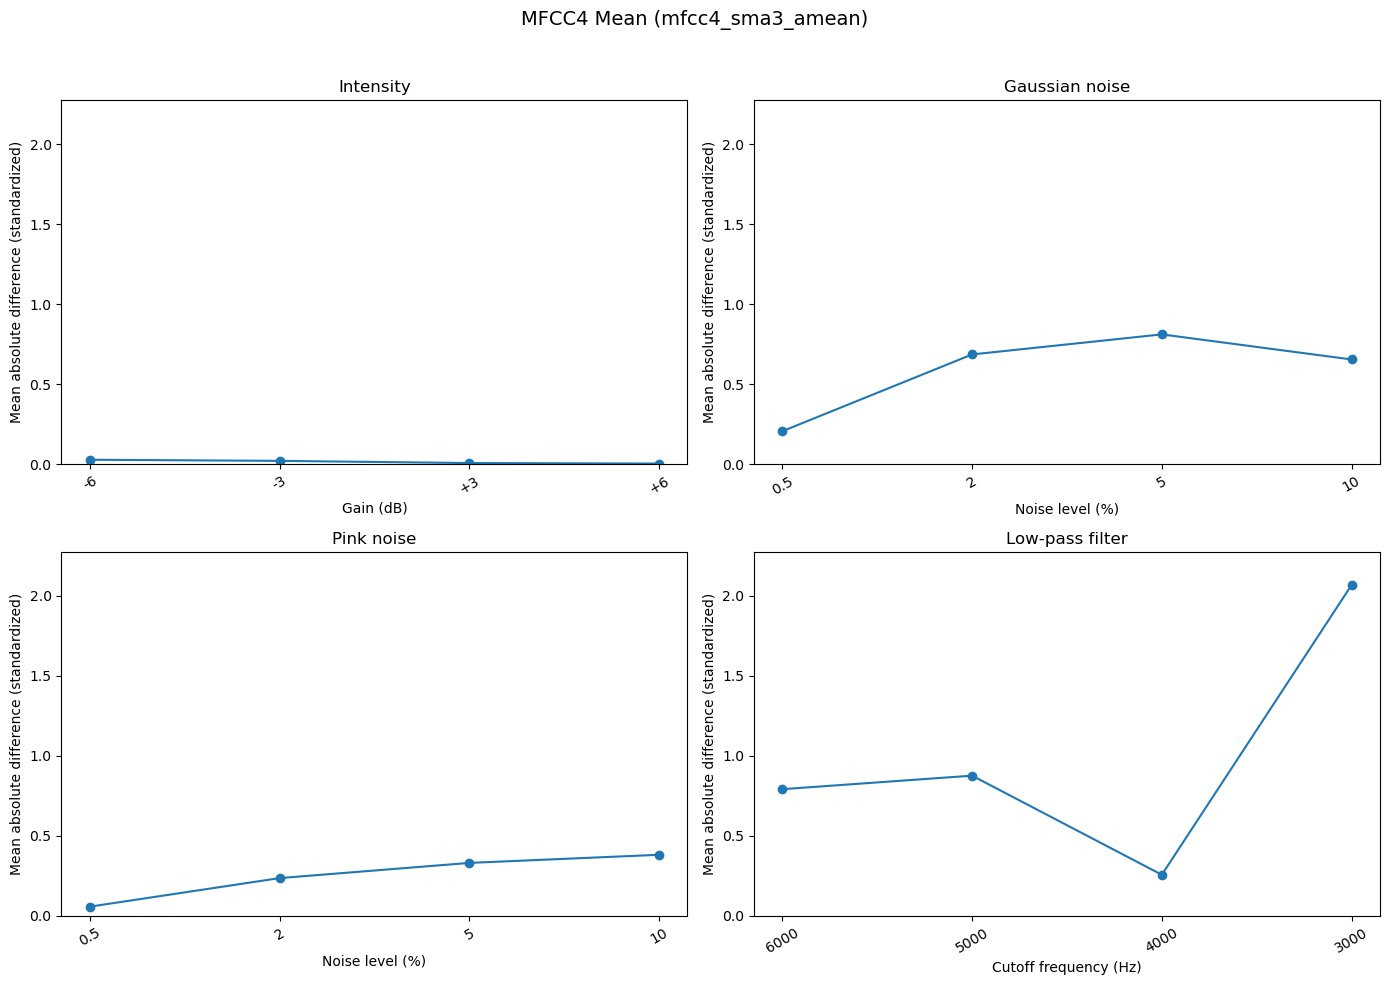

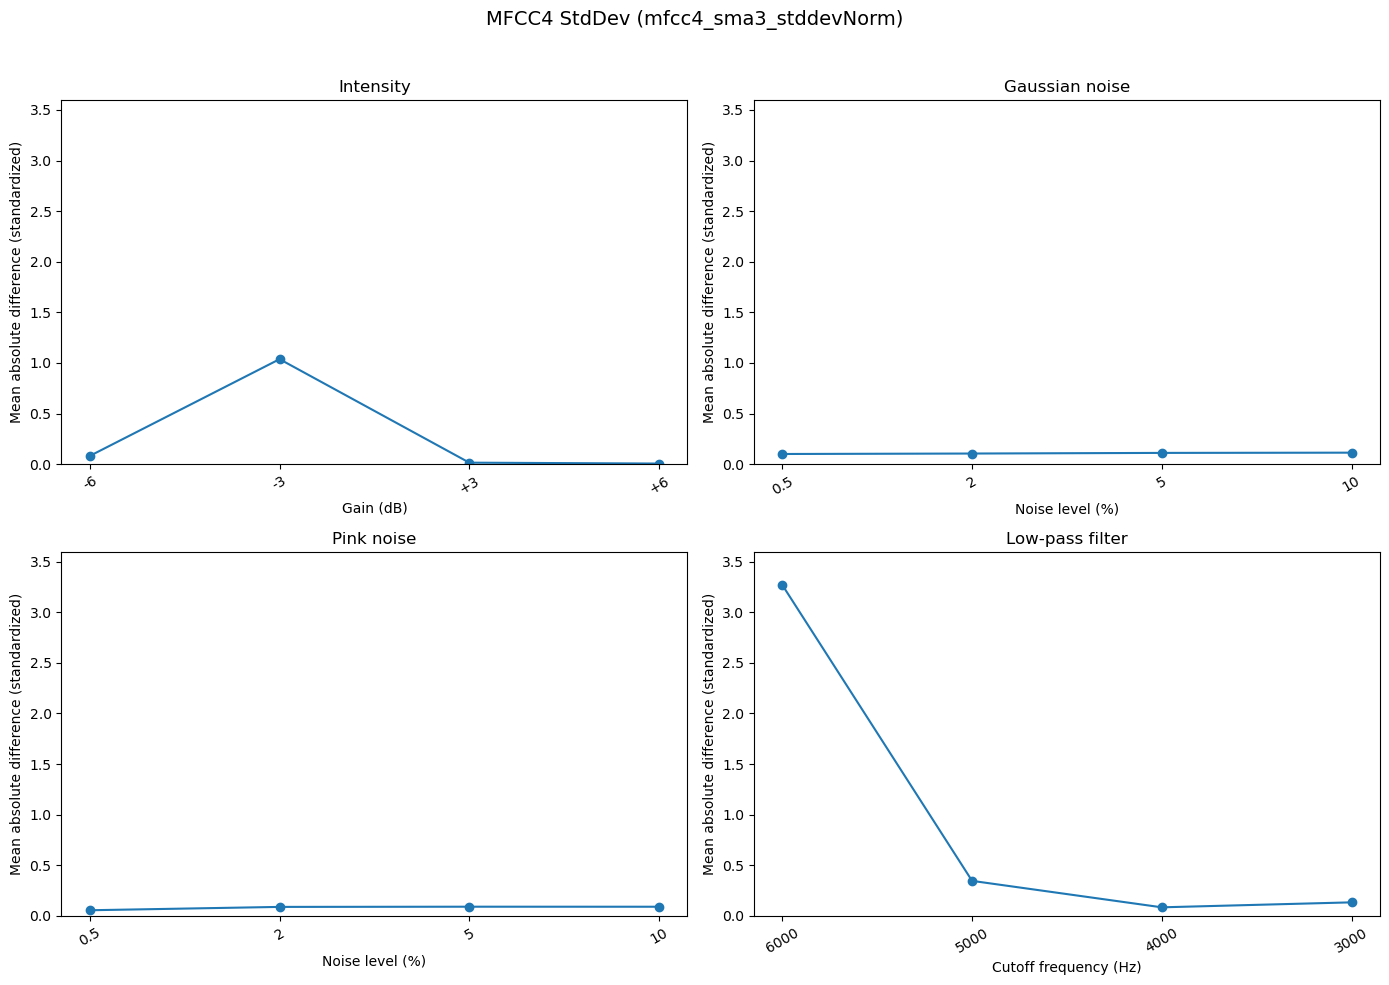

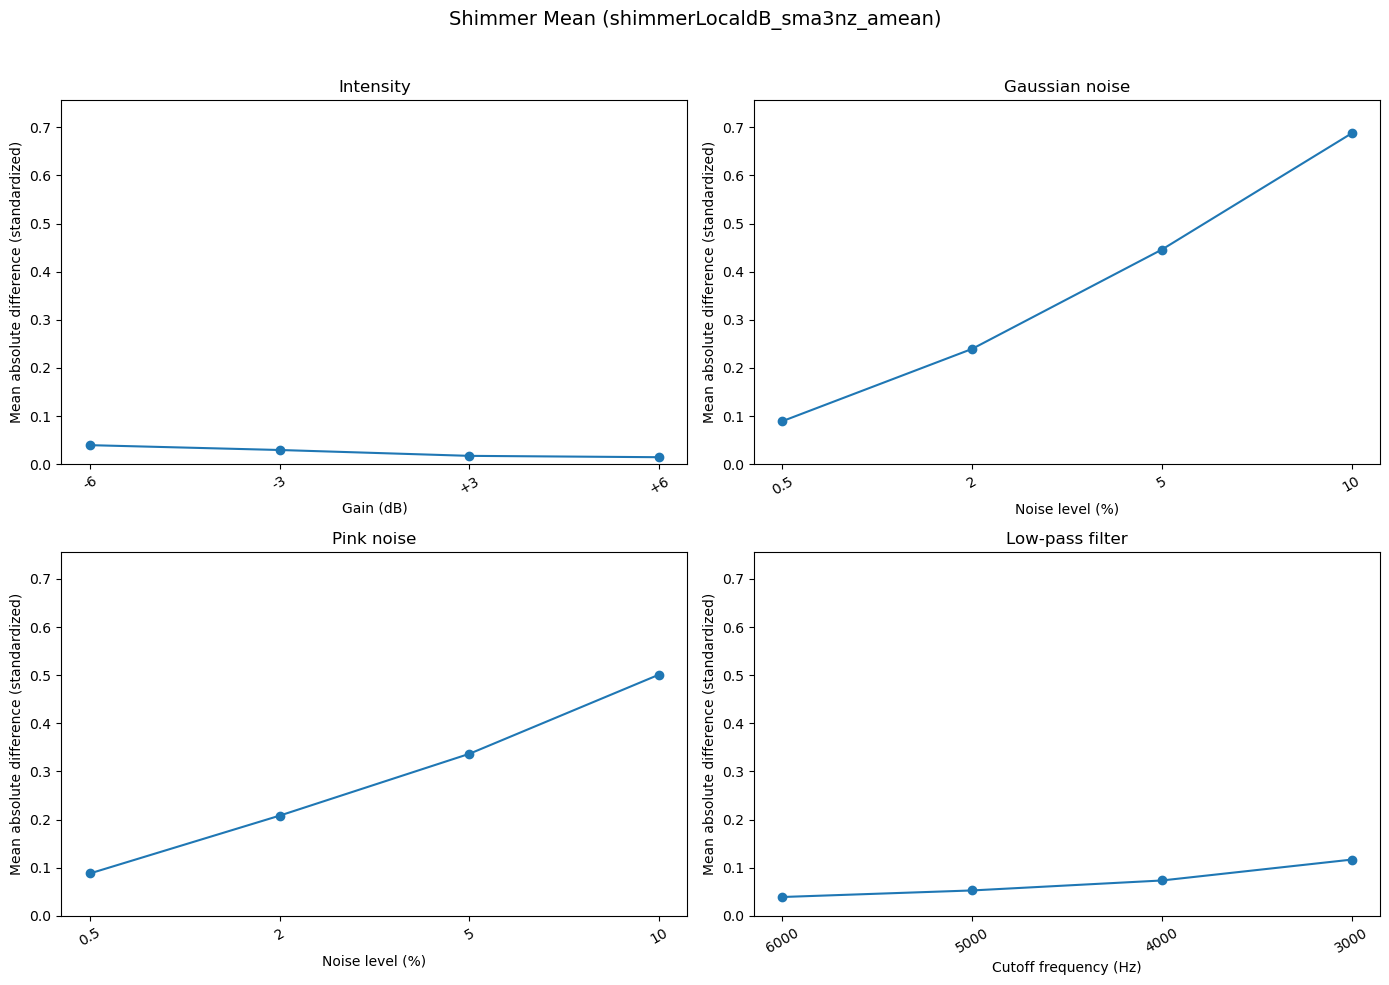

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# load
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

PLOTS_DIR = BASE_PATH / "feature_robustness_plots_standardized"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# features to plot 
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# files of the different perturbations
perturbation_groups = {
    "Intensity": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "-6": BASE_PATH / "opensmile_intensity_-6dB_features_pain.csv",
        "-3": BASE_PATH / "opensmile_intensity_-3dB_features_pain.csv",
        "+3": BASE_PATH / "opensmile_intensity_3dB_features_pain.csv",
        "+6": BASE_PATH / "opensmile_intensity_6dB_features_pain.csv",
    },
    "Gaussian noise": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "0.5": BASE_PATH / "opensmile_low_gaussian_features_pain.csv",
        "2": BASE_PATH / "opensmile_medium_gaussian_features_pain.csv",
        "5": BASE_PATH / "opensmile_high_gaussian_features_pain.csv",
        "10": BASE_PATH / "opensmile_very_high_gaussian_features_pain.csv",
    },
    "Pink noise": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "0.5": BASE_PATH / "opensmile_low_pink_features_pain.csv",
        "2": BASE_PATH / "opensmile_medium_pink_features_pain.csv",
        "5": BASE_PATH / "opensmile_high_pink_features_pain.csv",
        "10": BASE_PATH / "opensmile_very_high_pink_features_pain.csv",
    },
    "Low-pass filter": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "6000": BASE_PATH / "opensmile_low_lowpass_features_pain.csv",
        "5000": BASE_PATH / "opensmile_medium_lowpass_features_pain.csv",
        "4000": BASE_PATH / "opensmile_high_lowpass_features_pain.csv",
        "3000": BASE_PATH / "opensmile_very_high_lowpass_features_pain.csv",
    },
}

# Helper functions
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    df = df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)
    return df

def check_alignment(reference_df, comparison_df, label):
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")

def safe_filename(text):
    return (
        text.replace("%", "percent")
            .replace(" ", "_")
            .replace("/", "_")
            .replace("-", "_")
            .replace("(", "")
            .replace(")", "")
    )

# Load data
all_data = {}

for group_name, files in perturbation_groups.items():
    all_data[group_name] = {}
    for label, file_path in files.items():
        all_data[group_name][label] = load_and_sort_csv(file_path)

# Check alignment of all dataframes
for group_name, dfs in all_data.items():
    original_df = dfs["original"]

    for label, df in dfs.items():
        if label == "original":
            continue
        check_alignment(original_df, df, f"{group_name} - {label}")

# Check whether features exist in original dataframe
reference_original = all_data["Intensity"]["original"]

missing_features = [
    feature_col
    for feature_col in selected_features.values()
    if feature_col not in reference_original.columns
]

if missing_features:
    raise ValueError(f"These features are missing from the CSV: {missing_features}")

# Only selected feature columns will be standardized
feature_cols = list(selected_features.values())

# Fit scaler on original data only
scaler = StandardScaler()
scaler.fit(reference_original[feature_cols])

# Apply same standardization to all datasets
all_data_std = {}

for group_name, dfs in all_data.items():
    all_data_std[group_name] = {}

    for label, df in dfs.items():
        df_std = df.copy()
        df_std_features = scaler.transform(df[feature_cols])
        df_std[feature_cols] = df_std_features
        all_data_std[group_name][label] = df_std

# subplots using standardized data
for feature_name, feature_col in selected_features.items():

    # Collect all mean absolute differences to determine y-axis limits
    all_values = []

    for group_name, dfs in all_data_std.items():
        original_df = dfs["original"]

        for label, df in dfs.items():
            if label == "original":
                continue

            abs_diff = np.abs(original_df[feature_col] - df[feature_col])
            mean_abs_diff = abs_diff.mean()
            all_values.append(mean_abs_diff)

    # Y-axis limits
    y_min = 0
    y_max = max(all_values) * 1.1 if max(all_values) > 0 else 1

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (group_name, dfs) in zip(axes, all_data_std.items()):
        original_df = dfs["original"]

        x_labels = []
        mean_abs_diffs = []

        for label, df in dfs.items():
            if label == "original":
                continue

            abs_diff = np.abs(original_df[feature_col]- df[feature_col])
            mean_abs_diff = abs_diff.mean()

            x_labels.append(label)
            mean_abs_diffs.append(mean_abs_diff)

        ax.plot(x_labels, mean_abs_diffs, marker="o")
        ax.set_ylim(y_min, y_max)
        ax.set_title(group_name)

        if group_name == "Intensity":
            ax.set_xlabel("Gain (dB)")
        elif group_name == "Gaussian noise":
            ax.set_xlabel("Noise level (%)")
        elif group_name == "Pink noise":
            ax.set_xlabel("Noise level (%)")
        elif group_name == "Low-pass filter":
            ax.set_xlabel("Cutoff frequency (Hz)")

        ax.set_ylabel("Mean absolute difference (standardized)")
        ax.tick_params(axis="x", rotation=30)

    fig.suptitle(f"{feature_name} ({feature_col})", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    file_name = safe_filename(feature_name) + "_standardized.png"
    plt.savefig(PLOTS_DIR / file_name, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

Tabel toevoegen met gemiddelde van alle absolute verschillen over alle opnames en alle niveaus. En dit is gestandardiseerd omdat de waardes dan tussen de features met elkaar te vergelijken zijn

In [ ]:
# Create summary table
results = pd.DataFrame(
    index=selected_features.keys(),
    columns=perturbation_groups.keys()
)

# Calculate mean absolute differences for each feature and perturbation group
for feature_name, feature_col in selected_features.items():

    for group_name, dfs in all_data_std.items():
        original_df = dfs["original"]

        all_diffs = []

        for label, df in dfs.items(): # for each perturbation level
            if label == "original":
                continue

            abs_diff = np.abs(df[feature_col] - original_df[feature_col]) #absolute difference
            all_diffs.extend(abs_diff.values) # all the differences of the levels of perturbations are added to the list

        # one number per feature per perturbation group
        results.loc[feature_name, group_name] = np.mean(all_diffs) #mean of all the differences of the levels of perturbations is calculated and added to the results table

# save as float
results = results.astype(float)
results.to_csv(BASE_PATH / "feature_sensitivity_table.csv")

print(results)


                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.004665        0.194018    0.135247         0.009286
F0 20th%           0.004818        0.258035    0.180370         0.011633
F0 50th%           0.005057        0.087717    0.062535         0.011896
F0 80th%           0.001380        0.039412    0.028237         0.003187
F0 StdDev          0.010711        0.436674    0.304146         0.018735
F1 Mean            0.040946        0.347626    0.276891         0.099678
F1 StdDev          0.052725        0.384745    0.344140         0.125221
F2 Mean            0.040436        0.320573    0.271091         0.100593
F2 StdDev          0.061294        0.456678    0.388531         0.148707
F3 Mean            0.038705        0.500322    0.348421         0.109415
F3 StdDev          0.065147        0.576650    0.422839         0.191960
HNR Mean           0.006961        0.250425    0.186164         0.016496
HNR StdDev         0.002476        0.107640    0.09

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# load
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

PLOTS_DIR = BASE_PATH / "feature_robustness_plots_standardized"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# features to plot 
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# files of the different perturbations
perturbation_groups = {
    "Intensity": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "-6": BASE_PATH / "opensmile_intensity_-6dB_features_pain.csv",
        "-3": BASE_PATH / "opensmile_intensity_-3dB_features_pain.csv",
        "+3": BASE_PATH / "opensmile_intensity_3dB_features_pain.csv",
        "+6": BASE_PATH / "opensmile_intensity_6dB_features_pain.csv",
    },
    "Gaussian noise": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "0.5": BASE_PATH / "opensmile_low_gaussian_features_pain.csv",
        "2": BASE_PATH / "opensmile_medium_gaussian_features_pain.csv",
        "5": BASE_PATH / "opensmile_high_gaussian_features_pain.csv",
        "10": BASE_PATH / "opensmile_very_high_gaussian_features_pain.csv",
    },
    "Pink noise": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "0.5": BASE_PATH / "opensmile_low_pink_features_pain.csv",
        "2": BASE_PATH / "opensmile_medium_pink_features_pain.csv",
        "5": BASE_PATH / "opensmile_high_pink_features_pain.csv",
        "10": BASE_PATH / "opensmile_very_high_pink_features_pain.csv",
    },
    "Low-pass filter": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "6000": BASE_PATH / "opensmile_low_lowpass_features_pain.csv",
        "5000": BASE_PATH / "opensmile_medium_lowpass_features_pain.csv",
        "4000": BASE_PATH / "opensmile_high_lowpass_features_pain.csv",
        "3000": BASE_PATH / "opensmile_very_high_lowpass_features_pain.csv",
    },
}

# Helper functions
def load_and_sort_csv(file_path):
    df = pd.read_csv(file_path)
    df = df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)
    return df

def check_alignment(reference_df, comparison_df, label):
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")

# Load data
all_data = {}

for group_name, files in perturbation_groups.items():
    all_data[group_name] = {}
    for label, file_path in files.items():
        all_data[group_name][label] = load_and_sort_csv(file_path)

# Check alignment
for group_name, dfs in all_data.items():
    original_df = dfs["original"]
    for label, df in dfs.items():
        if label == "original":
            continue
        check_alignment(original_df, df, f"{group_name} - {label}")

# Check whether features exist
reference_original = all_data["Intensity"]["original"]

missing_features = [
    feature_col
    for feature_col in selected_features.values()
    if feature_col not in reference_original.columns
]

if missing_features:
    raise ValueError(f"These features are missing from the CSV: {missing_features}")

# --------------------------------------------------
# SUMMARY TABLE: STANDARDIZE DIFFERENCES PER LEVEL
# --------------------------------------------------
results = pd.DataFrame(
    index=selected_features.keys(),
    columns=perturbation_groups.keys()
)

for feature_name, feature_col in selected_features.items():

    for group_name, dfs in all_data.items():
        original_df = dfs["original"]

        level_scores = []

        for label, df in dfs.items():
            if label == "original":
                continue

            # 1. difference for this feature and this perturbation level
            diff = original_df[feature_col] - df[feature_col]

            # reshape for StandardScaler
            diff_array = diff.to_numpy().reshape(-1, 1)

            # 2. standardize differences WITHIN this level
            scaler = StandardScaler()
            diff_std = scaler.fit_transform(diff_array).flatten()

            # 3. absolute value
            abs_diff_std = np.abs(diff_std)

            # 4. mean for this level
            mean_abs_diff_std = abs_diff_std.mean()
            level_scores.append(mean_abs_diff_std)

        # 5. mean over all levels in this perturbation group
        results.loc[feature_name, group_name] = np.mean(level_scores)

# Save table
results = results.astype(float)
results.to_csv(BASE_PATH / "feature_sensitivity_table_standardized_diff_per_level.csv")

print(results)

                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.269830        0.666282    0.665830         0.296787
F0 20th%           0.109048        0.516351    0.438096         0.128838
F0 50th%           0.074232        0.296601    0.286291         0.104930
F0 80th%           0.126056        0.438172    0.394904         0.208585
F0 StdDev          0.264987        0.710597    0.679721         0.298041
F1 Mean            0.465010        0.719908    0.737957         0.598474
F1 StdDev          0.438978        0.734464    0.709917         0.550386
F2 Mean            0.515966        0.678658    0.741871         0.618387
F2 StdDev          0.475190        0.732772    0.719759         0.569602
F3 Mean            0.536396        0.670960    0.741743         0.635879
F3 StdDev          0.499762        0.746045    0.718869         0.600299
HNR Mean           0.276739        0.702697    0.682286         0.410892
HNR StdDev         0.135850        0.104850    0.09

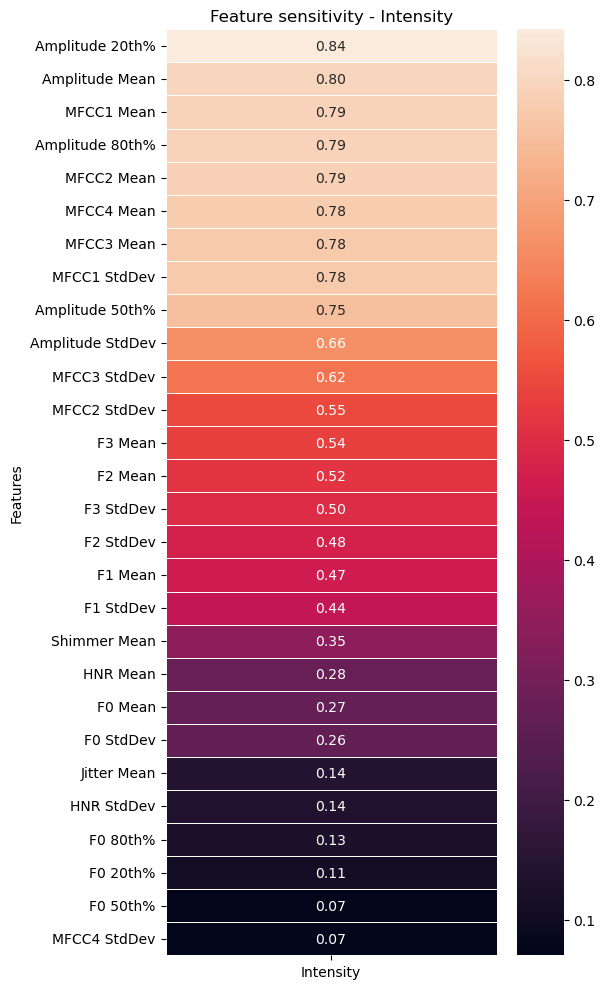

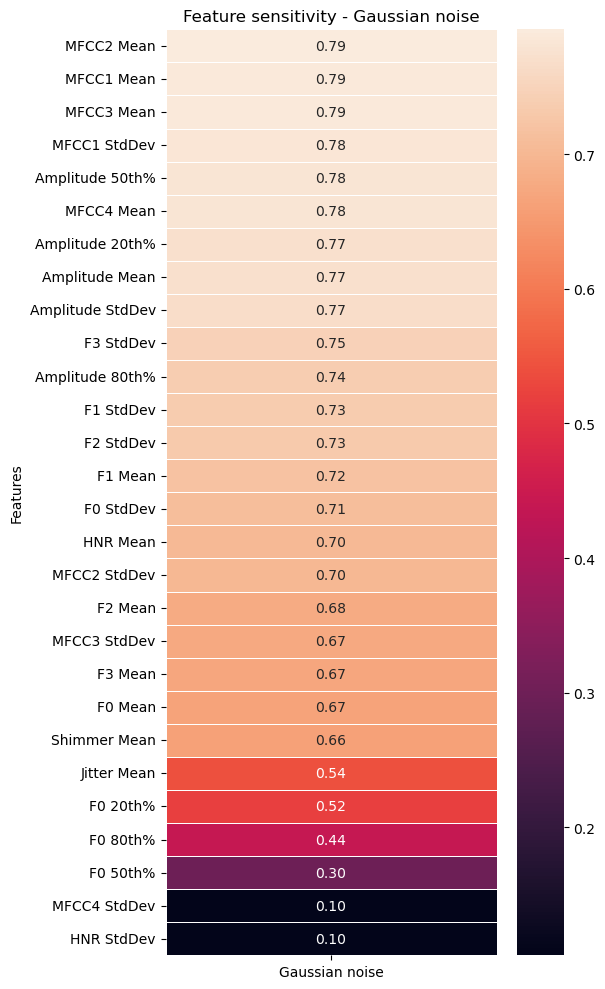

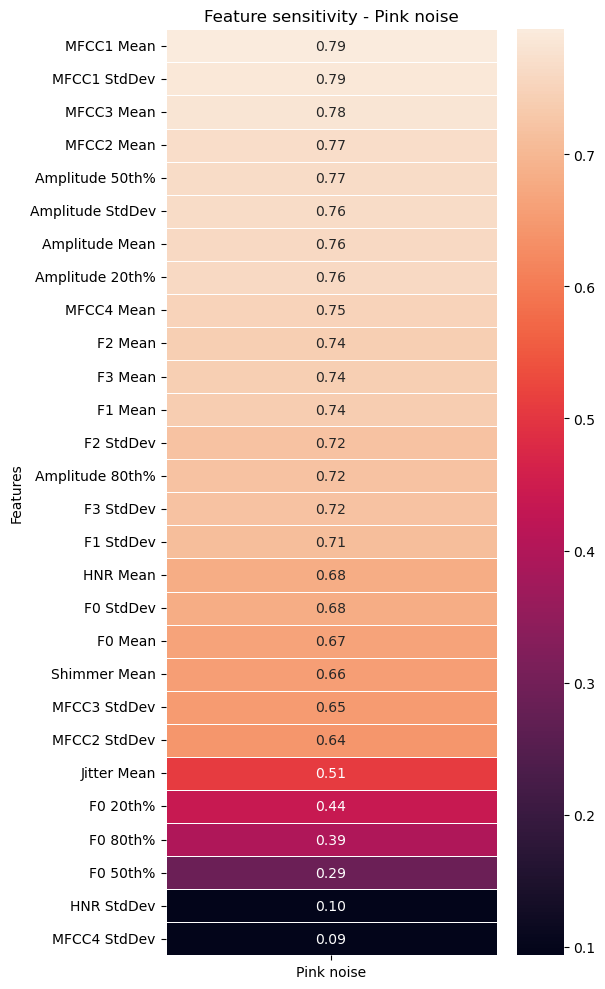

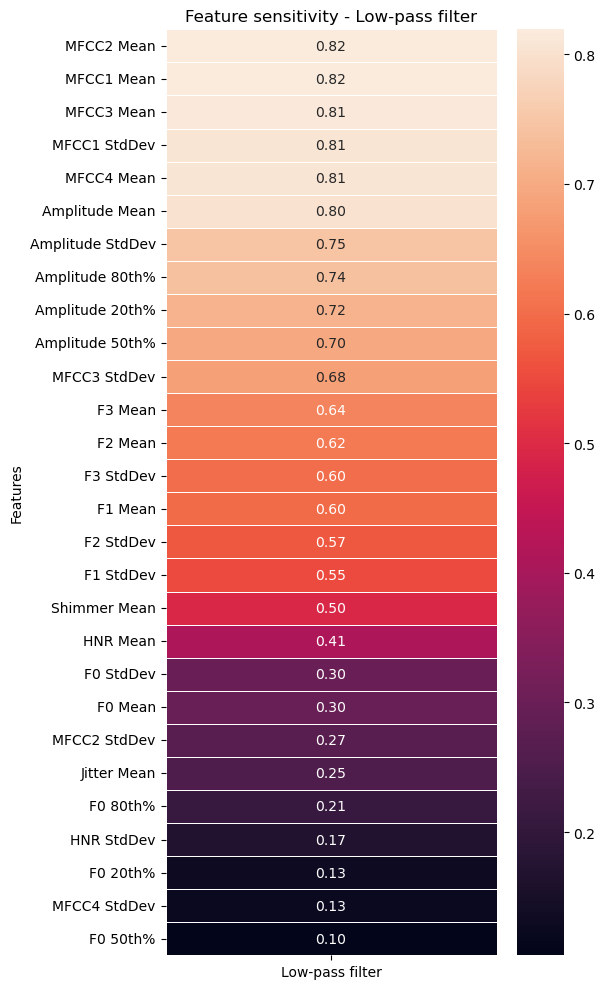

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# map om op te slaan
HEATMAP_DIR = BASE_PATH / "heatmaps_per_perturbation"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

for group_name in results.columns:

    # selecteer 1 kolom (perturbationgroep)
    data = results[[group_name]].copy()

    # sorteer van hoog naar laag (optioneel maar mooier)
    data = data.sort_values(by=group_name, ascending=False)

    plt.figure(figsize=(6, 10))

    sns.heatmap(
        data,
        annot=True,
        fmt=".2f",
        linewidths=0.5,
        cbar=True
    )

    plt.title(f"Feature sensitivity - {group_name}")
    plt.ylabel("Features")
    plt.xlabel("")

    plt.tight_layout()
    plt.savefig(HEATMAP_DIR / f"heatmap_{group_name}.png", dpi=300)
    plt.show()
    plt.close()